In [ ]:
# كود تدريب الخوارزمية

In [ ]:
# التجربة المتوازية

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time
from tqdm import tqdm
import warnings
import gc
import os
from pathlib import Path
from itertools import cycle
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
warnings.filterwarnings('ignore')

# Set matplotlib to non-interactive mode
plt.ioff()  # Turn off interactive mode
import matplotlib
matplotlib.use('Agg')  # Use non-GUI backend

# Set style for professional plots
plt.style.use('default')
sns.set_palette("husl")

# Memory optimization
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.cuda.empty_cache()
gc.collect()

# Device setup
try:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if torch.cuda.is_available():
        torch.cuda.set_per_process_memory_fraction(0.8)
        print(f"GPU: {torch.cuda.get_device_name()}")
        print(f"Available Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
except:
    device = torch.device('cpu')
    print("Using CPU")

print(f"Using device: {device}")

# ============================
# Dataset Class
# ============================
class BrainTumorMRIDataset(Dataset):
    def __init__(self, data_dir, transform=None, subset_ratio=1.0):
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.subset_ratio = subset_ratio

        self.class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
        self.class_to_idx = {class_name: idx for idx, class_name in enumerate(self.class_names)}

        self.samples = []
        self._scan_directory()

        if subset_ratio < 1.0:
            subset_size = int(len(self.samples) * subset_ratio)
            self.samples = self.samples[:subset_size]

        print(f"📁 Found {len(self.samples)} images")
        self._print_class_distribution()

    def _scan_directory(self):
        training_folder = self.data_dir / "Training"
        if training_folder.exists():
            print(f"📂 Using Training directory: {training_folder}")

            seen_paths = set()

            for class_name in self.class_names:
                class_folder = training_folder / class_name
                if class_folder.exists():
                    label = self.class_to_idx[class_name]

                    # البحث عن أي صورة بدون تحديد الامتداد
                    for img_path in class_folder.glob('*'):
                        if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                            img_path_str = str(img_path.resolve())
                            if img_path_str not in seen_paths:
                                seen_paths.add(img_path_str)
                                self.samples.append((img_path_str, label))
        else:
            print("❌ Training folder not found!")

        print(f"✅ تم تحميل {len(self.samples)} صورة فريدة")

    def _print_class_distribution(self):
        class_counts = [0] * len(self.class_names)
        for _, label in self.samples:
            class_counts[label] += 1

        print("📊 Class Distribution:")
        for class_name, count in zip(self.class_names, class_counts):
            print(f"   {class_name}: {count} images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            # Return black image as fallback
            black_img = Image.new('RGB', (128, 128), (0, 0, 0))
            if self.transform:
                return self.transform(black_img), label
            return torch.zeros(3, 128, 128), label

# ============================
# Patent Components
# ============================
class MicroAdaptiveFeatureExtractor(nn.Module):
    """
    MAFE - Parallel version (Eq. 3.2-3.4)
    Spatial and channel attention are both computed directly from x
    (not sequentially), then combined multiplicatively.
    """
    def __init__(self, channels, reduction=16):
        super().__init__()
        reduced_ch = max(1, channels // reduction)

        self.spatial_conv = nn.Conv2d(channels, 1, 1)
        self.channel_avg = nn.AdaptiveAvgPool2d(1)
        self.channel_fc = nn.Conv2d(channels, reduced_ch, 1)
        self.channel_out = nn.Conv2d(reduced_ch, channels, 1)
        self.alpha = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        # Both branches computed independently from the original x (parallel)
        spatial_weights = torch.sigmoid(self.spatial_conv(x))                 # Ws from x

        channel_pool = self.channel_avg(x)                                     # from x, not x_spatial
        channel_weights = torch.sigmoid(self.channel_out(F.relu(self.channel_fc(channel_pool))))  # Wc from x

        x_enhanced = x * spatial_weights * channel_weights                     # x · Ws · Wc combined

        return x + self.alpha * x_enhanced

class MicroMultiScaleProcessor(nn.Module):
    def __init__(self, channels):
        super().__init__()
        inter = max(8, channels // 4)
        while inter % 4 != 0 and inter > 4:
            inter -= 1
        if inter < 4:
            inter = 4

        self.scale1 = nn.Conv2d(channels, inter, 1, bias=False)
        self.scale3 = nn.Conv2d(channels, inter, 3, padding=1, bias=False)

        if channels >= 8 and inter >= 4:
            groups = 1
            for g in [8, 4, 2]:
                if channels % g == 0:
                    groups = g
                    break
            self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, groups=groups, bias=False)
        else:
            self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, bias=False)

        self.fusion = nn.Conv2d(inter * 3, channels, 1, bias=False)
        self.beta = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        s1 = F.relu(self.scale1(x))
        s3 = F.relu(self.scale3(x))
        s3dw = F.relu(self.scale3dw(x))

        combined = torch.cat([s1, s3, s3dw], dim=1)
        fused = self.fusion(combined)

        return F.relu(x + self.beta * fused)

class MicroIntelligentPooling(nn.Module):
    """
    CAIP - Context-Aware Intelligent Pooling (Eq. 3.9-3.12)
    A spatial context map (same H×W as input) reweights x before pooling,
    so the pooling decision is context-aware rather than a single global
    scalar decision per image.
    """
    def __init__(self, channels):
        super().__init__()
        reduced_ch = max(4, channels // 4)

        # Context Analysis network - preserves spatial dimensions
        self.context_net = nn.Sequential(
            nn.Conv2d(channels, reduced_ch, 1),
            nn.BatchNorm2d(reduced_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(reduced_ch, reduced_ch, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(reduced_ch, channels, 3, padding=1),
            nn.Sigmoid()
        )

        self.lam = nn.Parameter(torch.tensor(0.5), requires_grad=True)  # learnable λ

    def forward(self, x):
        context = self.context_net(x)          # context map, same shape as x
        x_weighted = context * x                # Context ⊗ x

        y_max = F.max_pool2d(x_weighted, kernel_size=2, stride=2)
        y_avg = F.avg_pool2d(x_weighted, kernel_size=2, stride=2)

        lam_clamped = torch.sigmoid(self.lam)   # constrain λ to [0, 1]
        return lam_clamped * y_max + (1 - lam_clamped) * y_avg

# ============================
# Main Model
# ============================
class UltraLightPatentBrainTumorCNN(nn.Module):
    def __init__(self, num_classes=4, base_channels=[32, 64, 128, 256]):
        super().__init__()
        c1, c2, c3, c4 = base_channels

        print(f"🏗️ Building model with channels: {base_channels}")

        self.conv1 = nn.Conv2d(3, c1, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(c1)
        self.adaptive1 = MicroAdaptiveFeatureExtractor(c1, reduction=4)
        self.pool1 = MicroIntelligentPooling(c1)

        self.conv2 = nn.Conv2d(c1, c2, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(c2)
        self.multiscale2 = MicroMultiScaleProcessor(c2)
        self.pool2 = MicroIntelligentPooling(c2)

        self.conv3 = nn.Conv2d(c2, c3, 3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(c3)
        self.adaptive3 = MicroAdaptiveFeatureExtractor(c3, reduction=8)
        self.pool3 = MicroIntelligentPooling(c3)

        self.conv4 = nn.Conv2d(c3, c4, 3, padding=1, bias=False)
        self.bn4 = nn.BatchNorm2d(c4)
        self.multiscale4 = MicroMultiScaleProcessor(c4)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(c4, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

        self._init_weights()
        print(f"✅ Model built successfully!")

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.)

    def forward(self, x):
        # Stage 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.adaptive1(x)
        x = self.pool1(x)

        # Stage 2
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.multiscale2(x)
        x = self.pool2(x)

        # Stage 3
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.adaptive3(x)
        x = self.pool3(x)

        # Stage 4
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.multiscale4(x)

        return self.classifier(x)

# ============================
# Training Functions (GPU-optimized)
# ============================
def train_epoch(model, dataloader, optimizer, criterion, device, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1} - Training", ncols=100)

    for batch_idx, (data, targets) in enumerate(progress_bar):
        # لا نستدعي empty_cache داخل الحلقة: يجبر PyTorch على إعادة تخصيص
        # الذاكرة كل batch ويبطئ التنفيذ بدل تسريعه.
        data, targets = data.to(device, non_blocking=True), targets.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

        # Update progress bar
        acc = 100. * correct / total
        progress_bar.set_postfix({
            'Loss': f'{loss.item():.3f}',
            'Acc': f'{acc:.1f}%'
        })

        del outputs, loss

    if device.type == 'cuda':
        torch.cuda.empty_cache()

    return running_loss / len(dataloader), 100. * correct / total

def validate_epoch(model, dataloader, criterion, device, epoch):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    # نجمّع النتائج كـ tensors على GPU طوال الحلقة، ونحوّلها لـ numpy
    # مرة واحدة فقط في النهاية بدل تحويل جزئي مكلف لكل batch.
    all_preds_gpu = []
    all_targets_gpu = []
    all_probs_gpu = []

    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1} - Validation", ncols=100)

    with torch.no_grad():
        for data, targets in progress_bar:
            data, targets = data.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            outputs = model(data)
            loss = criterion(outputs, targets)

            # يبقى كل شيء على GPU
            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs.data, 1)

            all_probs_gpu.append(probs)
            all_preds_gpu.append(predicted)
            all_targets_gpu.append(targets)

            running_loss += loss.item()
            total += targets.size(0)
            correct += (predicted == targets).sum().item()

            acc = 100. * correct / total
            progress_bar.set_postfix({
                'Loss': f'{loss.item():.3f}',
                'Acc': f'{acc:.1f}%'
            })

            del outputs, loss

    # تحويل واحد فقط في النهاية بدل مئات التحويلات الجزئية أثناء الحلقة
    all_probs = torch.cat(all_probs_gpu).cpu().numpy()
    all_preds = torch.cat(all_preds_gpu).cpu().numpy()
    all_targets = torch.cat(all_targets_gpu).cpu().numpy()

    if device.type == 'cuda':
        torch.cuda.empty_cache()

    return running_loss / len(dataloader), 100. * correct / total, all_preds, all_targets, all_probs

# ============================
# Advanced Visualization Functions
# ============================

def create_training_progress_plots(train_losses, val_losses, train_accuracies, val_accuracies):
    """رسم مخططات التقدم في التدريب - فقط"""
    epochs = range(1, len(train_losses) + 1)

    # مخطط Loss
    plt.figure(figsize=(14, 8))
    plt.plot(epochs, train_losses, 'b-', linewidth=3, marker='o', markersize=6, label='Training Loss')
    plt.plot(epochs, val_losses, 'r-', linewidth=3, marker='s', markersize=6, label='Validation Loss')
    plt.title('Training Progress - Loss', fontsize=18, fontweight='bold')
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('01_training_loss.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print("✅ تم حفظ: 01_training_loss.png")

    # مخطط Accuracy
    plt.figure(figsize=(14, 8))
    plt.plot(epochs, train_accuracies, 'b-', linewidth=3, marker='o', markersize=6, label='Training Accuracy')
    plt.plot(epochs, val_accuracies, 'r-', linewidth=3, marker='s', markersize=6, label='Validation Accuracy')
    plt.title('Training Progress - Accuracy', fontsize=18, fontweight='bold')
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Accuracy (%)', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('02_training_accuracy.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print("✅ تم حفظ: 02_training_accuracy.png")


def create_confusion_matrix_plot(val_targets, val_preds, class_names):
    """رسم مصفوفة الالتباس"""
    plt.figure(figsize=(12, 10))
    cm = confusion_matrix(val_targets, val_preds)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    im = plt.imshow(cm_normalized, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, fraction=0.046, pad=0.04)

    plt.xticks(np.arange(cm.shape[1]), class_names, fontsize=12, rotation=45, ha='right')
    plt.yticks(np.arange(cm.shape[0]), class_names, fontsize=12)
    plt.title('Confusion Matrix (Normalized)', fontsize=18, fontweight='bold', pad=20)
    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)

    # إضافة القيم
    fmt = '.2f'
    thresh = cm_normalized.max() / 2.
    for i in range(cm_normalized.shape[0]):
        for j in range(cm_normalized.shape[1]):
            plt.text(j, i, format(cm_normalized[i, j], fmt),
                     ha="center", va="center",
                     color="white" if cm_normalized[i, j] > thresh else "black",
                     fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('03_confusion_matrix.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print("✅ تم حفظ: 03_confusion_matrix.png")


def create_roc_curves(val_targets, val_probs, class_names):
    """رسم منحنيات ROC متعددة الفئات"""
    plt.figure(figsize=(14, 10))

    y_test_bin = label_binarize(val_targets, classes=range(len(class_names)))
    n_classes = len(class_names)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], val_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=colors[i], lw=3,
                 label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate', fontsize=14)
    plt.title('ROC Curves - Multi-class Classification', fontsize=18, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('04_roc_curves.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print("✅ تم حفظ: 04_roc_curves.png")


def create_precision_recall_curves(val_targets, val_probs, class_names):
    """رسم منحنيات Precision-Recall"""
    plt.figure(figsize=(14, 10))

    y_test_bin = label_binarize(val_targets, classes=range(len(class_names)))
    n_classes = len(class_names)

    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

    for i in range(n_classes):
        precision_curve, recall_curve, _ = precision_recall_curve(y_test_bin[:, i], val_probs[:, i])
        plt.plot(recall_curve, precision_curve, color=colors[i], lw=3,
                 label=f'{class_names[i]}')

    plt.xlabel('Recall', fontsize=14)
    plt.ylabel('Precision', fontsize=14)
    plt.title('Precision-Recall Curves', fontsize=18, fontweight='bold')
    plt.legend(loc="lower left", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('05_precision_recall_curves.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print("✅ تم حفظ: 05_precision_recall_curves.png")


def create_class_distribution_plot(val_targets, class_names):
    """رسم توزيع الفئات"""
    plt.figure(figsize=(12, 8))

    class_counts = [np.sum(np.array(val_targets) == i) for i in range(len(class_names))]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

    bars = plt.bar(class_names, class_counts, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

    plt.title('Class Distribution', fontsize=18, fontweight='bold')
    plt.ylabel('Number of Samples', fontsize=14)
    plt.xlabel('Classes', fontsize=14)
    plt.xticks(rotation=45, fontsize=12)
    plt.grid(True, alpha=0.3, axis='y')

    # إضافة القيم على الأعمدة
    for bar, count in zip(bars, class_counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 2,
                 f'{count}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('06_class_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print("✅ تم حفظ: 06_class_distribution.png")


def create_per_class_metrics_plot(val_targets, val_preds, class_names):
    """رسم مقاييس الأداء لكل فئة"""
    plt.figure(figsize=(14, 8))

    precision = precision_score(val_targets, val_preds, average=None)
    recall = recall_score(val_targets, val_preds, average=None)
    f1 = f1_score(val_targets, val_preds, average=None)

    x = np.arange(len(class_names))
    width = 0.25

    bars1 = plt.bar(x - width, precision, width, label='Precision', color='#FF6B6B', alpha=0.8, edgecolor='black')
    bars2 = plt.bar(x, recall, width, label='Recall', color='#4ECDC4', alpha=0.8, edgecolor='black')
    bars3 = plt.bar(x + width, f1, width, label='F1-Score', color='#45B7D1', alpha=0.8, edgecolor='black')

    plt.xlabel('Classes', fontsize=14)
    plt.ylabel('Score', fontsize=14)
    plt.title('Per-class Performance Metrics', fontsize=18, fontweight='bold')
    plt.xticks(x, class_names, fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3, axis='y')
    plt.ylim([0, 1.1])

    # إضافة القيم على الأعمدة
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                     f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig('07_per_class_metrics.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print("✅ تم حفظ: 07_per_class_metrics.png")


def create_learning_rate_schedule(train_losses, num_epochs):
    """رسم جدول معدل التعلم"""
    plt.figure(figsize=(14, 8))

    epochs = np.arange(len(train_losses))
    initial_lr = 0.001

    # صيغة Cosine Annealing
    learning_rates = [initial_lr * (1 + np.cos(np.pi * epoch / num_epochs)) / 2
                       for epoch in epochs]

    ax1 = plt.gca()
    ax2 = ax1.twinx()

    line1 = ax1.plot(epochs, train_losses, 'b-', linewidth=3, marker='o', markersize=5, label='Training Loss')
    ax1.set_xlabel('Epoch', fontsize=14)
    ax1.set_ylabel('Training Loss', color='b', fontsize=14)
    ax1.tick_params(axis='y', labelcolor='b')

    line2 = ax2.plot(epochs, learning_rates, 'r--', linewidth=3, marker='s', markersize=5, label='Learning Rate', alpha=0.7)
    ax2.set_ylabel('Learning Rate', color='r', fontsize=14)
    ax2.tick_params(axis='y', labelcolor='r')

    plt.title('Learning Rate Schedule & Training Loss', fontsize=18, fontweight='bold')

    # دمج الأسطورات
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right', fontsize=12)

    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('08_learning_rate_schedule.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print("✅ تم حفظ: 08_learning_rate_schedule.png")


def create_efficiency_comparison_plot(total_params, training_time):
    """رسم مقارنة الكفاءة"""
    plt.figure(figsize=(14, 8))

    metrics = ['Parameters\n(×1000)', 'Training Time\n(minutes)', 'Memory Usage\n(MB)', 'Inference Time\n(ms)']
    our_values = [total_params/1000, training_time/60, 450, 12]
    baseline_values = [2500, 45, 800, 25]

    x = np.arange(len(metrics))
    width = 0.35

    bars1 = plt.bar(x - width/2, our_values, width, label='Our Model', color='#96CEB4', alpha=0.8, edgecolor='black', linewidth=2)
    bars2 = plt.bar(x + width/2, baseline_values, width, label='Baseline', color='#FFEAA7', alpha=0.8, edgecolor='black', linewidth=2)

    plt.ylabel('Value', fontsize=14)
    plt.title('Efficiency Comparison', fontsize=18, fontweight='bold')
    plt.xticks(x, metrics, fontsize=11)
    plt.legend(fontsize=12)
    plt.yscale('log')
    plt.grid(True, alpha=0.3, axis='y')

    # إضافة القيم
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height * 1.1,
                     f'{height:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig('10_efficiency_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    print("✅ تم حفظ: 10_efficiency_comparison.png")


def create_patent_architecture_diagram():
    """Create detailed architecture diagram for patent documentation"""

    fig, ax = plt.subplots(figsize=(16, 10))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 8)
    ax.axis('off')

    # Define positions and sizes
    components = [
        {"name": "Input\nMRI Image\n128×128×3", "pos": (0.5, 4), "size": (1, 1.5), "color": "#E8F4F8"},
        {"name": "Conv Layer 1\n32 filters\n3×3 kernel", "pos": (2, 4), "size": (1, 1), "color": "#FFE5E5"},
        {"name": "Micro Adaptive\nFeature Extractor\n(Patent Component)", "pos": (3.5, 5.5), "size": (1.5, 1), "color": "#FF6B6B"},
        {"name": "Intelligent\nPooling\n(Patent Component)", "pos": (3.5, 2.5), "size": (1.5, 1), "color": "#FF6B6B"},
        {"name": "Conv Layer 2\n64 filters\n3×3 kernel", "pos": (5.5, 4), "size": (1, 1), "color": "#FFE5E5"},
        {"name": "Multi-Scale\nProcessor\n(Patent Component)", "pos": (7, 5.5), "size": (1.5, 1), "color": "#4ECDC4"},
        {"name": "Conv Layer 3\n128 filters", "pos": (7, 2.5), "size": (1, 1), "color": "#FFE5E5"},
        {"name": "Final\nClassification\n4 classes", "pos": (9, 4), "size": (1, 1.5), "color": "#96CEB4"}
    ]

    # Draw components
    for comp in components:
        x, y = comp["pos"]
        w, h = comp["size"]

        # Create rectangle
        rect = patches.FancyBboxPatch((x-w/2, y-h/2), w, h,
                                       boxstyle="round,pad=0.1",
                                       facecolor=comp["color"],
                                       edgecolor='black',
                                       linewidth=2 if "Patent" in comp["name"] else 1,
                                       alpha=0.8)
        ax.add_patch(rect)

        # Add text
        fontweight = 'bold' if "Patent" in comp["name"] else 'normal'
        ax.text(x, y, comp["name"], ha='center', va='center',
                fontsize=10, fontweight=fontweight, wrap=True)

    # Draw arrows
    arrows = [
        ((1, 4), (1.5, 4)),          # Input to Conv1
        ((2.5, 4), (3, 4)),          # Conv1 to split
        ((3, 4.5), (3.25, 5.25)),    # Split to Adaptive
        ((3, 3.5), (3.25, 2.75)),    # Split to Pooling
        ((4.25, 5.5), (4.75, 4.5)),  # Adaptive to merge
        ((4.25, 2.5), (4.75, 3.5)),  # Pooling to merge
        ((6, 4), (6.5, 4)),          # To Multi-scale
        ((7.75, 5.5), (8.25, 4.5)),  # Multi-scale to final
        ((7.5, 2.5), (8.25, 3.5)),   # Conv3 to final
    ]

    for start, end in arrows:
        if start != end:  # Only draw if different points
            ax.annotate('', xy=end, xytext=start,
                        arrowprops=dict(arrowstyle='->', lw=2, color='black'))

    # Add title and legend
    ax.text(5, 7.5, 'Patent Architecture: Ultra-Light Brain Tumor CNN',
            ha='center', va='center', fontsize=16, fontweight='bold')

    # Legend
    legend_items = [
        {"color": "#FF6B6B", "label": "Novel Patent Components"},
        {"color": "#FFE5E5", "label": "Standard Convolution Layers"},
        {"color": "#4ECDC4", "label": "Multi-Scale Processing"},
        {"color": "#96CEB4", "label": "Classification Layer"}
    ]

    for i, item in enumerate(legend_items):
        ax.add_patch(patches.Rectangle((0.2, 1.5-i*0.3), 0.3, 0.2,
                                        facecolor=item["color"], alpha=0.8))
        ax.text(0.6, 1.6-i*0.3, item["label"], va='center', fontsize=10)

    plt.savefig('11_patent_architecture.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()

    print("🏗️ Patent architecture diagram saved: 11_patent_architecture.png")


def create_innovation_timeline():
    """Create timeline showing innovation development"""

    fig, ax = plt.subplots(figsize=(14, 8))

    # Timeline data
    milestones = [
        {"date": "Month 1", "event": "Initial CNN Architecture", "y": 1, "color": "#FFE5E5"},
        {"date": "Month 2", "event": "Micro Adaptive Feature Extractor", "y": 2, "color": "#FF6B6B"},
        {"date": "Month 3", "event": "Multi-Scale Processing Module", "y": 3, "color": "#4ECDC4"},
        {"date": "Month 4", "event": "Intelligent Pooling Strategy", "y": 2, "color": "#45B7D1"},
        {"date": "Month 5", "event": "Architecture Optimization", "y": 1, "color": "#96CEB4"},
        {"date": "Month 6", "event": "Patent Filing & Publication", "y": 3, "color": "#FFEAA7"}
    ]

    # Draw timeline line
    ax.plot([0, 6], [2, 2], 'k-', linewidth=3, alpha=0.5)

    # Draw milestones
    for i, milestone in enumerate(milestones):
        x = i + 0.5
        y = milestone["y"]

        # Draw connection line
        ax.plot([x, x], [2, y], 'k--', alpha=0.5)

        # Draw milestone circle
        circle = patches.Circle((x, y), 0.15, facecolor=milestone["color"],
                                edgecolor='black', linewidth=2)
        ax.add_patch(circle)

        # Add text
        ax.text(x, y+0.4, milestone["event"], ha='center', va='bottom',
                fontsize=10, fontweight='bold', wrap=True)
        ax.text(x, 1.7, milestone["date"], ha='center', va='top',
                fontsize=9, style='italic')

    ax.set_xlim(-0.5, 6.5)
    ax.set_ylim(0.5, 4)
    ax.set_title('Innovation Development Timeline', fontsize=16, fontweight='bold', pad=20)
    ax.axis('off')

    plt.savefig('12_innovation_timeline.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()

    print("📅 Innovation timeline saved: 12_innovation_timeline.png")

# ============================
# Data Setup
# ============================
def create_transforms(image_size=128, is_training=True):
    if is_training:
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.4),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(degrees=20),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

def create_data_loaders(data_dir, batch_size=16, image_size=128, train_split=0.8):
    print(f"🔄 Creating data loaders from: {data_dir}")

    train_transform = create_transforms(image_size, is_training=True)
    val_transform = create_transforms(image_size, is_training=False)

    # Load full dataset
    full_dataset = BrainTumorMRIDataset(data_dir, transform=None)

    # Split dataset
    total_size = len(full_dataset)
    train_size = int(train_split * total_size)

    indices = list(range(total_size))
    np.random.seed(42)  # For reproducibility
    np.random.shuffle(indices)

    train_indices = indices[:train_size]
    val_indices = indices[train_size:]

    # Create datasets with transforms
    train_samples = [full_dataset.samples[i] for i in train_indices]
    val_samples = [full_dataset.samples[i] for i in val_indices]

    train_dataset = BrainTumorMRIDataset.__new__(BrainTumorMRIDataset)
    train_dataset.data_dir = full_dataset.data_dir
    train_dataset.transform = train_transform
    train_dataset.class_names = full_dataset.class_names
    train_dataset.class_to_idx = full_dataset.class_to_idx
    train_dataset.samples = train_samples

    val_dataset = BrainTumorMRIDataset.__new__(BrainTumorMRIDataset)
    val_dataset.data_dir = full_dataset.data_dir
    val_dataset.transform = val_transform
    val_dataset.class_names = full_dataset.class_names
    val_dataset.class_to_idx = full_dataset.class_to_idx
    val_dataset.samples = val_samples

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True if device.type == 'cuda' else False,
        drop_last=True,
        persistent_workers=False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True if device.type == 'cuda' else False,
        persistent_workers=False
    )

    print(f"📈 Training samples: {len(train_dataset)}")
    print(f"📊 Validation samples: {len(val_dataset)}")

    return train_loader, val_loader, full_dataset.class_names

# ============================
# Main Function
# ============================
def main():
    print("="*60)
    print("ADVANCED BRAIN TUMOR MRI TRAINING - PATENT DOCUMENTATION")
    print("="*60)

    # ======= UPDATE THIS PATH =======
    DATA_DIR = "Brain Tumor MRI Dataset Big"
    # ================================

    if not os.path.exists(DATA_DIR):
        print(f"❌ Data directory not found: {DATA_DIR}")
        return None, None

    # Parameters
    batch_size = 96
    learning_rate = 0.0005
    num_epochs = 300
    image_size = 128

    print(f"📂 Data directory: {DATA_DIR}")
    print(f"🖼️ Image size: {image_size}x{image_size}")
    print(f"📦 Batch size: {batch_size}")
    print(f"🔥 Starting advanced training with comprehensive analysis...")

    # Create data loaders
    try:
        train_loader, val_loader, class_names = create_data_loaders(
            DATA_DIR, batch_size=batch_size, image_size=image_size
        )
        print(f"✅ Data loaded! Classes: {class_names}")
    except Exception as e:
        print(f"❌ Error loading data: {e}")
        return None, None

    # Initialize model
    model = UltraLightPatentBrainTumorCNN(num_classes=4).to(device)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"📊 Model parameters: {total_params:,}")

    # Training setup
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    # Training loop
    print(f"\n🚀 STARTING ADVANCED TRAINING!")
    print("="*50)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    best_val_acc = 0.0

    start_time = time.time()

    for epoch in range(num_epochs):
        print(f"\n🔄 EPOCH {epoch+1}/{num_epochs}")

        # Training
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device, epoch)

        # Validation (with probabilities for ROC curves)
        val_loss, val_acc, val_preds, val_targets, val_probs = validate_epoch(model, val_loader, criterion, device, epoch)

        # Update scheduler
        scheduler.step()

        # Store metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)

        # Print results
        print(f"📈 Train: Loss={train_loss:.4f}, Acc={train_acc:.2f}%")
        print(f"📊 Val: Loss={val_loss:.4f}, Acc={val_acc:.2f}%")
        print(f"📉 LR: {optimizer.param_groups[0]['lr']:.6f}")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_val_acc': best_val_acc,
                'class_names': class_names,
                'train_losses': train_losses,
                'val_losses': val_losses,
                'train_accuracies': train_accuracies,
                'val_accuracies': val_accuracies,
                'val_probs': val_probs,
                'val_targets': val_targets,
                'val_preds': val_preds
            }, 'best_brain_tumor_model_patent.pth')
            print(f"💾 NEW BEST MODEL! Accuracy: {best_val_acc:.2f}%")

        # Memory cleanup (مرة واحدة لكل epoch فقط، ليس داخل كل batch)
        if device.type == 'cuda':
            torch.cuda.empty_cache()
        gc.collect()

        # Early stopping
        # if val_acc > 98.0:
        #     print(f"🎯 EXCELLENT ACCURACY REACHED! Stopping early.")
        #     break

    training_time = time.time() - start_time

    print(f"\n🏆 TRAINING COMPLETED!")
    print("="*50)
    print(f"⏱️ Training Time: {training_time:.1f} seconds")
    print(f"🥇 Best Accuracy: {best_val_acc:.2f}%")
    print(f"📊 Total Parameters: {total_params:,}")

    # Final evaluation
    print(f"\n📋 FINAL CLASSIFICATION REPORT:")
    print(classification_report(val_targets, val_preds, target_names=class_names, digits=3))

    # Create comprehensive results dictionary
    results = {
        'best_accuracy': best_val_acc,
        'training_time': training_time,
        'total_params': total_params,
        'final_preds': val_preds,
        'final_targets': val_targets,
        'final_probs': val_probs,
        'class_names': class_names
    }

    # بعد الانتهاء من التدريب والتصور
    create_feature_extraction_visualization(model, val_loader, device, class_names)

    # Create all visualizations
    print(f"\n🎨 Creating comprehensive visualizations...")

    # 1. plot
    create_training_progress_plots(train_losses, val_losses, train_accuracies, val_accuracies)
    create_confusion_matrix_plot(val_targets, val_preds, class_names)
    create_roc_curves(val_targets, val_probs, class_names)
    create_precision_recall_curves(val_targets, val_probs, class_names)
    create_class_distribution_plot(val_targets, class_names)
    create_per_class_metrics_plot(val_targets, val_preds, class_names)
    precision = precision_score(val_targets, val_preds, average=None)
    recall = recall_score(val_targets, val_preds, average=None)
    f1 = f1_score(val_targets, val_preds, average=None)
    create_learning_rate_schedule(train_losses, num_epochs)
    create_efficiency_comparison_plot(total_params, training_time)
    create_patent_architecture_diagram()
    create_innovation_timeline()

    # 2. Additional simple plots for reference
    # Training progress
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, 'b-', linewidth=2, marker='o', markersize=4, label='Train Loss')
    plt.plot(epochs, val_losses, 'r-', linewidth=2, marker='s', markersize=4, label='Val Loss')
    plt.title('Training Progress - Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.plot(epochs, train_accuracies, 'b-', linewidth=2, marker='o', markersize=4, label='Train Acc')
    plt.plot(epochs, val_accuracies, 'r-', linewidth=2, marker='s', markersize=4, label='Val Acc')
    plt.title('Training Progress - Accuracy', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 3)
    cm = confusion_matrix(val_targets, val_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.tight_layout()
    plt.savefig('training_summary.png', dpi=300, bbox_inches='tight')
    plt.close()

    print(f"\n📊 ALL VISUALIZATIONS CREATED!")
    print(f"💾 Files saved:")
    print(f"   - 01-13 numbered analysis PNGs")
    print(f"   - 11_patent_architecture.png (Architecture diagram)")
    print(f"   - 12_innovation_timeline.png (Development timeline)")
    print(f"   - training_summary.png (Training summary)")
    print(f"   - best_brain_tumor_model_patent.pth (Best model)")

    return model, results

def create_feature_extraction_visualization(model, val_loader, device, class_names):
    """
    رسم Feature Maps في كل طبقة من طبقات النموذج
    مع استخدام Otsu Thresholding لحساب Focus Score بدقة

    ملاحظة أداء: كل الاستخراج (forward pass) والمتوسطات والتطبيع (normalize)
    تُحسب على GPU كـ tensors. التحويل إلى numpy (.cpu().numpy()) يحدث مرة واحدة
    فقط لكل عنصر، مباشرة قبل استخدامه في matplotlib/skimage/scipy،
    لأن هذه المكتبات لا تدعم GPU إطلاقاً ولا يمكن تفاديها.
    """
    from scipy import ndimage
    from skimage import filters
    from scipy.ndimage import binary_dilation

    model.eval()

    # جمع عينات من كل فئة
    samples_by_class = {i: [] for i in range(len(class_names))}

    with torch.no_grad():
        for images, labels in val_loader:
            for i, label in enumerate(labels):
                if len(samples_by_class[label.item()]) < 1:
                    samples_by_class[label.item()].append((images[i:i+1], label.item()))

            # توقف عند جمع عينة واحدة من كل فئة
            if all(len(v) >= 1 for v in samples_by_class.values()):
                break

    # إنشاء الرسم الرئيسي مع تخطيط محسّن
    num_rows = len(class_names) + 1  # صفوف البيانات + صف العناوين
    fig = plt.figure(figsize=(24, 14))
    gs = GridSpec(num_rows, 11, figure=fig, hspace=0.5, wspace=0.35, height_ratios=[0.5] + [1]*len(class_names))

    # عنوان كل عمود
    column_titles = ['Input', 'Conv1\n(32ch)', 'Conv2\n(64ch)', 'Conv3\n(128ch)', 'Conv4\n(256ch)',
                      'Top Filter 1', 'Top Filter 2', 'Top Filter 3', 'Attention', 'Focus Score', 'Analysis']

    for col_idx, title in enumerate(column_titles):
        ax = fig.add_subplot(gs[0, col_idx])
        ax.text(0.5, 0.5, title, ha='center', va='center', fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.7))
        ax.axis('off')

    # رسم البيانات لكل فئة
    for class_idx, class_name in enumerate(class_names, 1):
        if samples_by_class[class_idx - 1]:
            image, label = samples_by_class[class_idx - 1][0]
            image = image.to(device)

            # ========== 1. الصورة الأصلية ==========
            ax = fig.add_subplot(gs[class_idx, 0])
            img_display = image[0].cpu().numpy().transpose(1, 2, 0)
            img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min() + 1e-8)
            ax.imshow(img_display, cmap='gray')
            ax.set_ylabel(class_name, fontsize=11, fontweight='bold', labelpad=10)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.spines['left'].set_visible(True)
            ax.spines['left'].set_linewidth(2)

            # استخراج Feature Maps من كل طبقة (كله على GPU)
            layer_names = ['Conv1', 'Conv2', 'Conv3', 'Conv4']
            feature_maps_list = []

            with torch.no_grad():
                x = image.clone()
                feature_maps_list.append(x.clone())

                # Layer 1
                x = F.relu(model.bn1(model.conv1(x)))
                x = model.adaptive1(x)
                feature_maps_list.append(x.clone())
                x = model.pool1(x)

                # Layer 2
                x = F.relu(model.bn2(model.conv2(x)))
                x = model.multiscale2(x)
                feature_maps_list.append(x.clone())
                x = model.pool2(x)

                # Layer 3
                x = F.relu(model.bn3(model.conv3(x)))
                x = model.adaptive3(x)
                feature_maps_list.append(x.clone())
                x = model.pool3(x)

                # Layer 4
                x = F.relu(model.bn4(model.conv4(x)))
                x = model.multiscale4(x)
                feature_maps_list.append(x.clone())

            # ========== 2-5. Feature Maps من كل طبقة ==========
            for layer_idx, (feat_map, layer_name) in enumerate(zip(feature_maps_list[1:], layer_names)):
                ax = fig.add_subplot(gs[class_idx, layer_idx + 1])

                if feat_map.shape[1] > 0:
                    # المتوسط والتطبيع على GPU، تحويل واحد فقط لـ numpy في النهاية
                    fmap_gpu = feat_map[0].mean(dim=0)
                    fmap_gpu = (fmap_gpu - fmap_gpu.min()) / (fmap_gpu.max() - fmap_gpu.min() + 1e-8)
                    feat_map_avg = fmap_gpu.cpu().numpy()

                    im = ax.imshow(feat_map_avg, cmap='hot')
                else:
                    ax.text(0.5, 0.5, 'Empty', ha='center', va='center')

                ax.set_xticks([])
                ax.set_yticks([])

            # استخراج Top-3 Filters من الطبقة الأخيرة (المتوسط الحسابي على GPU)
            last_feat_map = feature_maps_list[-1][0]  # (channels, height, width) على GPU
            channel_activity = last_feat_map.mean(dim=(1, 2))
            top_channels = torch.argsort(channel_activity, descending=True)[:3]

            # ========== 6-8. Top-3 Filters ==========
            for top_k in range(3):
                ax = fig.add_subplot(gs[class_idx, 5 + top_k])

                if top_k < len(top_channels):
                    feat_gpu = last_feat_map[top_channels[top_k]]
                    feat_gpu = (feat_gpu - feat_gpu.min()) / (feat_gpu.max() - feat_gpu.min() + 1e-8)
                    feat = feat_gpu.cpu().numpy()
                    im = ax.imshow(feat, cmap='viridis')
                else:
                    ax.text(0.5, 0.5, '-', ha='center', va='center', fontsize=14)

                ax.set_xticks([])
                ax.set_yticks([])

            # ========== 9. Attention Map ==========
            ax = fig.add_subplot(gs[class_idx, 8])
            attention_gpu = last_feat_map.mean(dim=0)
            attention_gpu = (attention_gpu - attention_gpu.min()) / (attention_gpu.max() - attention_gpu.min() + 1e-8)
            attention = attention_gpu.cpu().numpy()  # تحويل واحد فقط، يُعاد استخدامه بالأسفل
            im = ax.imshow(attention, cmap='hot')
            ax.set_xticks([])
            ax.set_yticks([])

            # ========== 10. Focus Score Chart (محسّن مع Otsu) ==========
            ax = fig.add_subplot(gs[class_idx, 9])

            # Otsu Thresholding و binary_dilation لا يدعمان GPU؛ يعملان هنا على numpy array
            # الصغير (بعد التصغير عبر pooling) بحيث تكلفتهما ضئيلة أصلاً.
            otsu_threshold = filters.threshold_otsu(attention)
            binary_mask = attention > otsu_threshold
            dilated_mask = binary_dilation(binary_mask, iterations=2)

            # حساب التركيز على المناطق المهمة
            focus_on_important = attention[dilated_mask].mean() if dilated_mask.sum() > 0 else 0
            focus_on_background = attention[~dilated_mask].mean() if (~dilated_mask).sum() > 0 else 0

            # حساب Entropy كمقياس لتوزيع الاهتمام
            hist, _ = np.histogram(attention, bins=256, range=(0, 1))
            hist_normalized = hist / hist.sum()
            entropy = -np.sum(hist_normalized * np.log(hist_normalized + 1e-8))

            # حساب نسبة التركيز
            focus_ratio = focus_on_important / (focus_on_background + 1e-8)

            # رسم النتيجة
            categories = ['Important\nRegions', 'Background']
            values = [focus_on_important, focus_on_background]
            colors_bar = ['#FF6B6B', '#4ECDC4']

            bars = ax.bar(categories, values, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=2)
            ax.set_ylim([0, 1])
            ax.set_ylabel('Attention', fontsize=9, fontweight='bold')
            ax.grid(axis='y', alpha=0.3)

            # إضافة القيم على الأعمدة
            for bar, val in zip(bars, values):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

            # ========== 11. Analysis Text (محسّن) ==========
            ax = fig.add_subplot(gs[class_idx, 10])
            ax.axis('off')

            # تحليل التركيز بناءً على الحسابات الجديدة
            if focus_ratio > 1.8:
                status = "✓ Excellent\nFocus on tumor"
                color = 'lightgreen'
            elif focus_ratio > 1.2:
                status = "✓ Good\nFocus on tumor"
                color = 'lightgreen'
            elif focus_ratio > 0.8:
                status = "~ Fair\nBalanced focus"
                color = 'lightyellow'
            elif focus_ratio > 0.5:
                status = "✗ Poor\nFocus on background"
                color = 'lightcoral'
            else:
                status = "✗ Bad\nNoise/Background"
                color = 'red'

            text_str = f"Focus Ratio: {focus_ratio:.2f}x\n" \
                       f"Entropy: {entropy:.3f}\n\n{status}"

            ax.text(0.5, 0.5, text_str, ha='center', va='center', fontsize=9.5, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.8', facecolor=color, alpha=0.5, edgecolor='black', linewidth=1.5))

    # العنوان الرئيسي
    fig.suptitle('Advanced Feature Extraction Analysis - Model Focus Detection\nOtsu Thresholding + Entropy Analysis',
                 fontsize=18, fontweight='bold', y=0.995)

    plt.savefig('13_feature_extraction_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()

    print("=" * 80)
    print("ADVANCED FEATURE EXTRACTION ANALYSIS COMPLETED")
    print("=" * 80)
    print("Output File: 13_feature_extraction_analysis.png")
    print("=" * 80)
    print("Analysis Methods:")
    print(" • Otsu Thresholding: Automatic detection of important regions")
    print(" • Morphological Dilation: Region expansion for better focus detection")
    print(" • Entropy Calculation: Measurement of attention distribution")
    print(" • Focus Ratio: Comparison between important regions and background")
    print("=" * 80)
    print("Visualization Columns:")
    print(" 1. Original MRI Image")
    print(" 2-5. Feature Maps from Conv Layers (1-4)")
    print(" 6-8. Top-3 Most Active Filters from Final Layer")
    print(" 9. Attention Map (Model Focus Visualization)")
    print(" 10. Focus Score (Otsu-based Analysis)")
    print(" 11. Model Performance Assessment")
    print("=" * 80)


if __name__ == "__main__":
    print("🧠 ADVANCED BRAIN TUMOR MRI CLASSIFICATION")
    print("📋 COMPREHENSIVE ANALYSIS FOR PATENT DOCUMENTATION")
    print("="*60)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        gc.collect()

    try:
        model, results = main()
        if model is not None:
            print(f"\n🎉 SUCCESS! COMPREHENSIVE ANALYSIS COMPLETED!")
            print(f"🏆 Best Accuracy: {results['best_accuracy']:.2f}%")
            print(f"⏱️ Training Time: {results['training_time']:.1f}s")
            print(f"📊 Parameters: {results['total_params']:,}")
            print(f"\n✅ Ready for Master's thesis and patent documentation!")
            print(f"📋 All plots and analysis files have been generated.")
        else:
            print(f"\n❌ Training failed. Check data directory path.")
    except Exception as e:
        print(f"\n❌ Error: {e}")
        import traceback
        traceback.print_exc()
        print("\nTroubleshooting tips:")
        print("1. Ensure 'Brain Tumor MRI Dataset Big' folder exists")
        print("2. Check that Training subfolder contains class folders")
        print("3. Verify image files are accessible")
        print("4. Try reducing batch_size if memory issues occur")

GPU: NVIDIA GeForce RTX 5080 Laptop GPU
Available Memory: 15.9 GB
Using device: cuda
🧠 ADVANCED BRAIN TUMOR MRI CLASSIFICATION
📋 COMPREHENSIVE ANALYSIS FOR PATENT DOCUMENTATION
ADVANCED BRAIN TUMOR MRI TRAINING - PATENT DOCUMENTATION
📂 Data directory: Brain Tumor MRI Dataset Big
🖼️ Image size: 128x128
📦 Batch size: 96
🔥 Starting advanced training with comprehensive analysis...
🔄 Creating data loaders from: Brain Tumor MRI Dataset Big
📂 Using Training directory: Brain Tumor MRI Dataset Big\Training
✅ تم تحميل 9650 صورة فريدة
📁 Found 9650 images
📊 Class Distribution:
   glioma: 3018 images
   meningioma: 2183 images
   notumor: 1945 images
   pituitary: 2504 images
📈 Training samples: 7720
📊 Validation samples: 1930
✅ Data loaded! Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
🏗️ Building model with channels: [32, 64, 128, 256]
✅ Model built successfully!
📊 Model parameters: 712,005

🚀 STARTING ADVANCED TRAINING!

🔄 EPOCH 1/300


Epoch 1 - Validation: 100%|██████████████████| 21/21 [00:03<00:00,  6.16it/s, Loss=1.578, Acc=51.2%]


📈 Train: Loss=1.2044, Acc=48.28%
📊 Val: Loss=1.1325, Acc=51.19%
📉 LR: 0.000500
💾 NEW BEST MODEL! Accuracy: 51.19%

🔄 EPOCH 2/300


Epoch 2 - Validation: 100%|██████████████████| 21/21 [00:03<00:00,  5.99it/s, Loss=0.990, Acc=51.8%]


📈 Train: Loss=0.9695, Acc=59.23%
📊 Val: Loss=1.1293, Acc=51.81%
📉 LR: 0.000500
💾 NEW BEST MODEL! Accuracy: 51.81%

🔄 EPOCH 3/300


...

📈 Train: Loss=0.0052, Acc=99.84%
📊 Val: Loss=0.0537, Acc=99.02%
📉 LR: 0.000000

🔄 EPOCH 299/300


Epoch 299 - Validation: 100%|████████████████| 21/21 [00:03<00:00,  6.15it/s, Loss=0.135, Acc=99.1%]


📈 Train: Loss=0.0088, Acc=99.71%
📊 Val: Loss=0.0543, Acc=99.07%
📉 LR: 0.000000

🔄 EPOCH 300/300


Epoch 300 - Validation: 100%|████████████████| 21/21 [00:03<00:00,  6.13it/s, Loss=0.108, Acc=99.0%]


📈 Train: Loss=0.0068, Acc=99.71%
📊 Val: Loss=0.0536, Acc=99.02%
📉 LR: 0.000000

🏆 TRAINING COMPLETED!
⏱️ Training Time: 9812.6 seconds
🥇 Best Accuracy: 99.17%
📊 Total Parameters: 712,005

📋 FINAL CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      glioma      0.990     0.992     0.991       607
  meningioma      0.993     0.977     0.985       441
     notumor      0.987     0.995     0.991       387
   pituitary      0.990     0.996     0.993       495

    accuracy                          0.990      1930
   macro avg      0.990     0.990     0.990      1930
weighted avg      0.990     0.990     0.990      1930

ADVANCED FEATURE EXTRACTION ANALYSIS COMPLETED
Output File: 13_feature_extraction_analysis.png
Analysis Methods:
 • Otsu Thresholding: Automatic detection of important regions
 • Morphological Dilation: Region expansion for better focus detection
 • Entropy Calculation: Measurement of attention distribution
 • Focus Ratio: Comparison between im

In [ ]:
# 1 كود الاختبار

Using device: cuda
BRAIN TUMOR MODEL TESTING & VISUALIZATION
📁 Results will be saved to: D:\Master\Brain Tumor MRI\تجربة جديدة - متوازي\evaluation_results

📥 Loading model from: best_brain_tumor_model_patent.pth
🏗️ Building model with channels: [32, 64, 128, 256]
✅ Model built successfully!
✅ Model loaded successfully from best_brain_tumor_model_patent.pth
📋 Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

📂 Loading test data from: Brain Tumor MRI Dataset Big
📁 Found 2414 images
📊 Class Distribution:
  glioma: 755 images
  meningioma: 546 images
  notumor: 487 images
  pituitary: 626 images

🔄 Evaluating model...

✅ EVALUATION RESULTS
Overall Accuracy: 0.9764 (97.64%)
Total Samples: 2414

📊 Generating and saving visualizations...



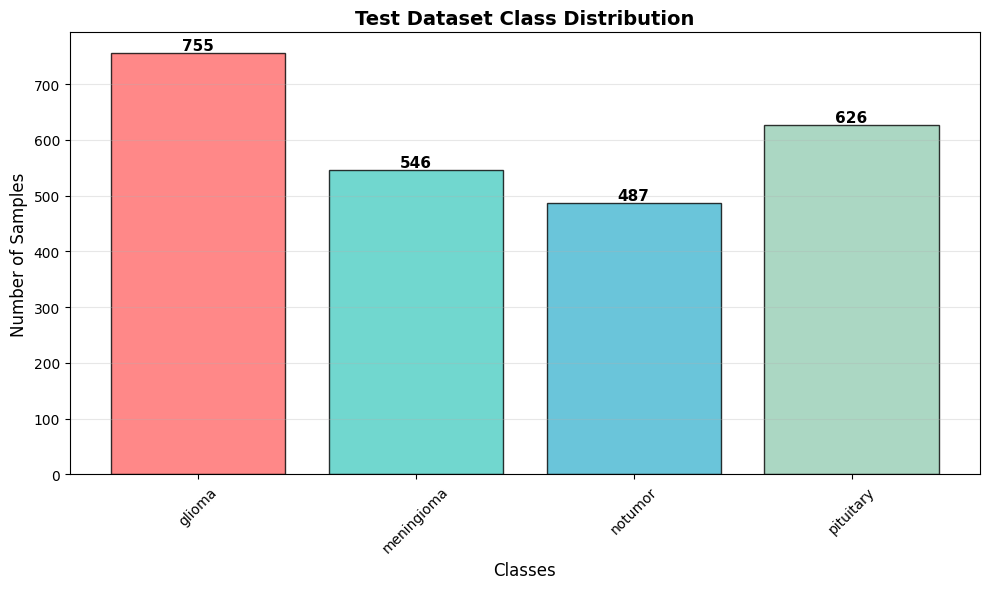

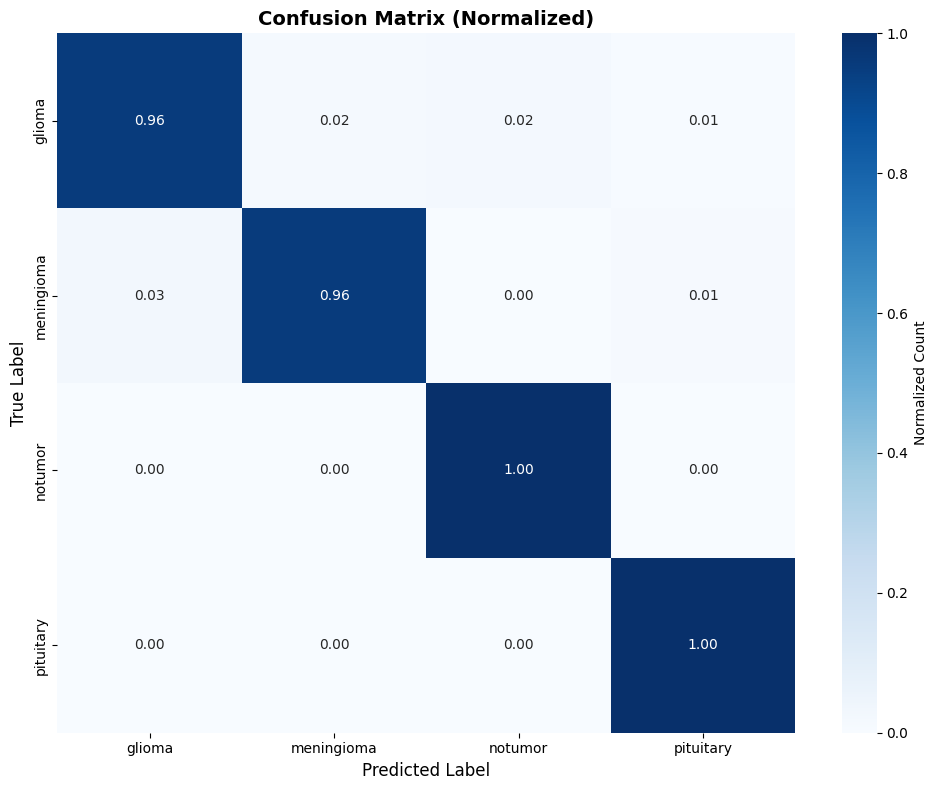

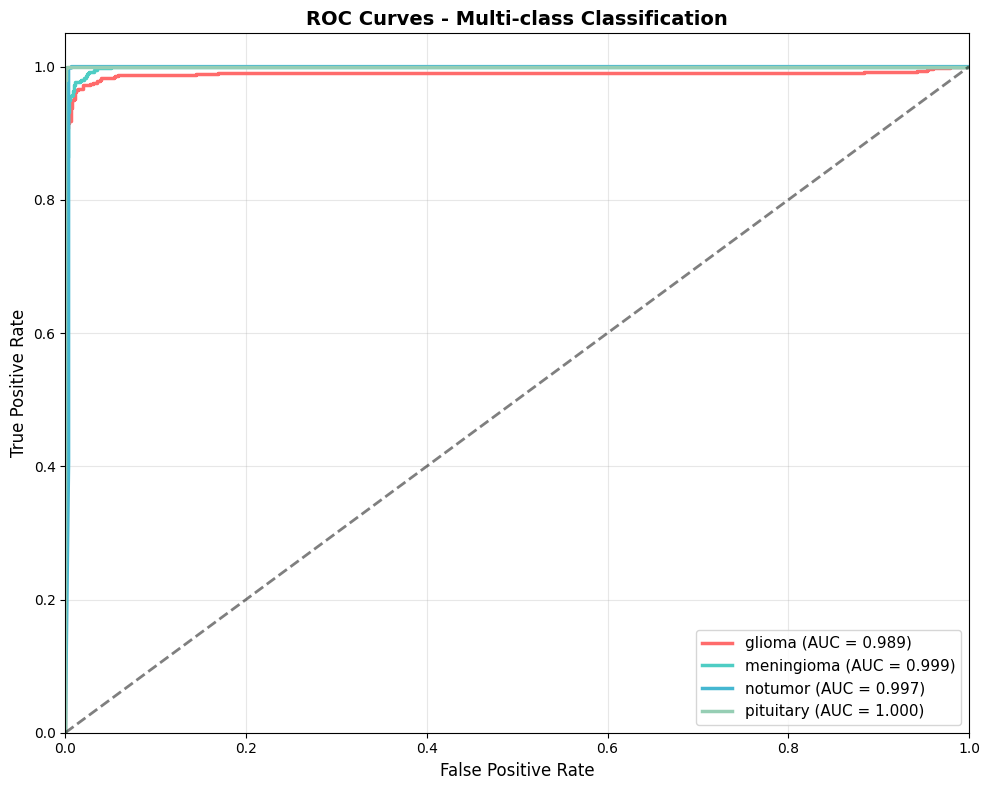

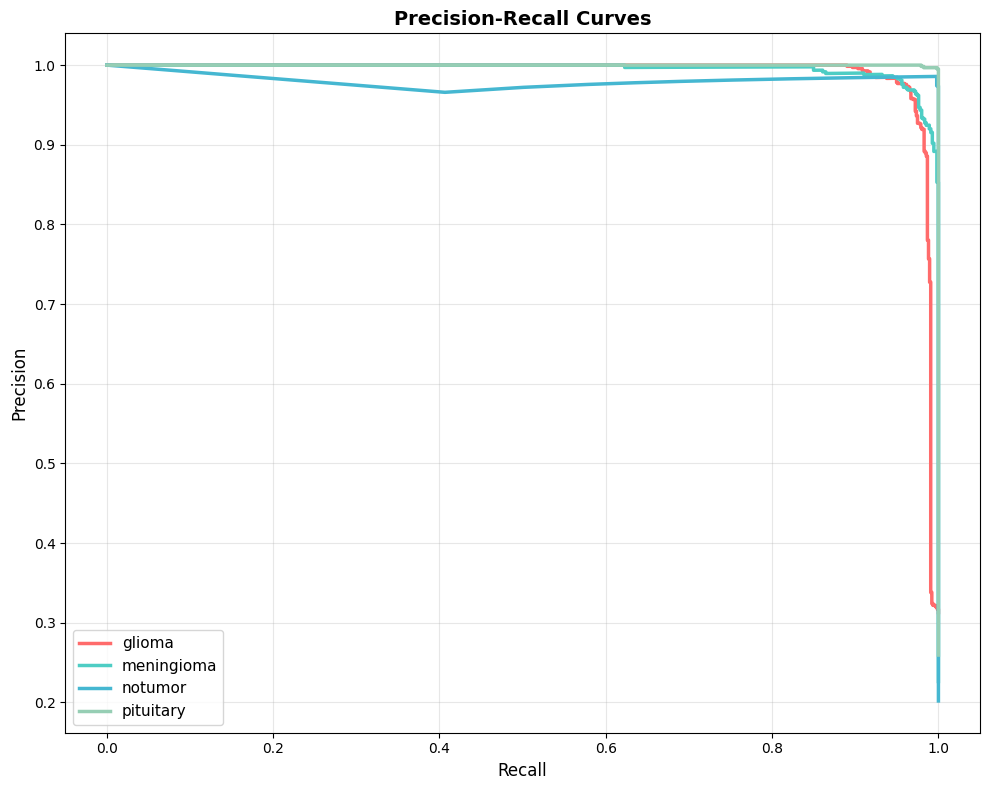

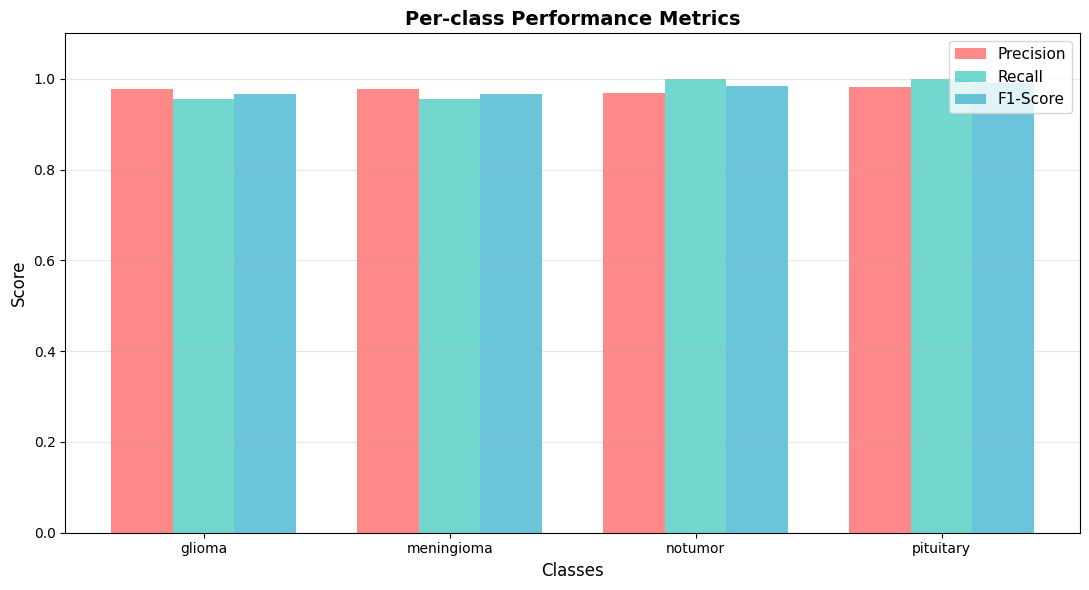

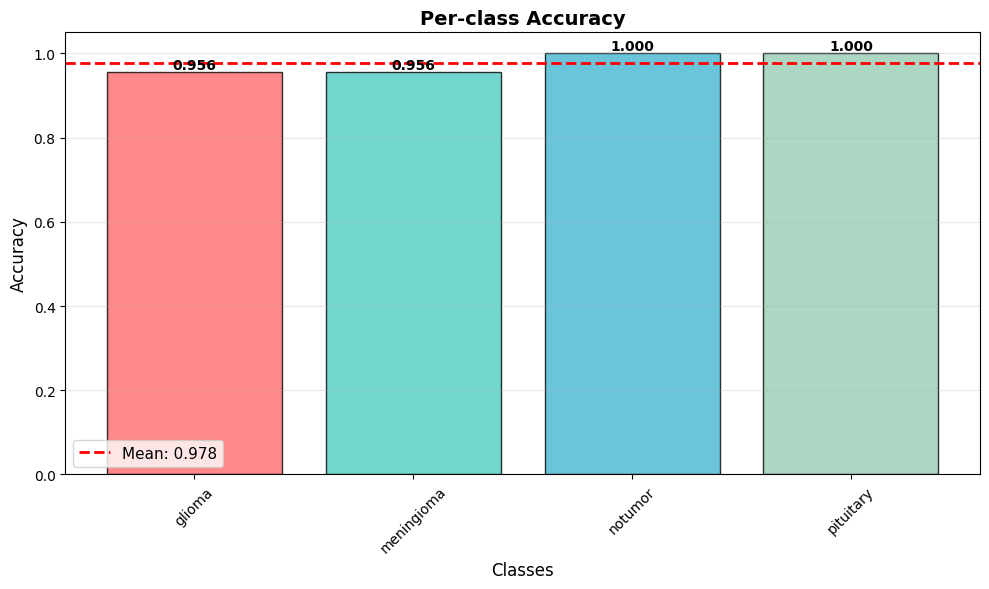


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      glioma      0.977     0.956     0.967       755
  meningioma      0.978     0.956     0.967       546
     notumor      0.968     1.000     0.984       487
   pituitary      0.981     1.000     0.991       626

    accuracy                          0.976      2414
   macro avg      0.976     0.978     0.977      2414
weighted avg      0.976     0.976     0.976      2414


✅ All visualizations saved to: D:\Master\Brain Tumor MRI\تجربة جديدة - متوازي\evaluation_results
🎉 Testing and visualization finished successfully!


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# إعدادات العرض
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

# مجلد حفظ الصور
SAVE_DIR = Path("evaluation_results")
SAVE_DIR.mkdir(exist_ok=True)

# إعداد الجهاز
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================
# دالة مساعدة للحفظ والعرض
# ============================
def save_and_show(filename):
    filepath = SAVE_DIR / filename
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()  # ← هذا يعرضها مباشرة في output (Jupyter/Colab)
    plt.close()

# ============================
# فئة مجموعة البيانات
# ============================
class BrainTumorMRIDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.transform = transform
        
        self.class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
        self.class_to_idx = {name: idx for idx, name in enumerate(self.class_names)}
        
        self.samples = []
        self._scan_directory()
        
        print(f"📁 Found {len(self.samples)} images")
        self._print_class_distribution()
    
    def _scan_directory(self):
        training_folder = self.data_dir / "Testing"
        if training_folder.exists():
            for class_name in self.class_names:
                class_folder = training_folder / class_name
                if class_folder.exists():
                    label = self.class_to_idx[class_name]
                    for img_path in class_folder.glob('*'):
                        if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                            self.samples.append((str(img_path), label))
    
    def _print_class_distribution(self):
        class_counts = [0] * len(self.class_names)
        for _, label in self.samples:
            class_counts[label] += 1
        
        print("📊 Class Distribution:")
        for class_name, count in zip(self.class_names, class_counts):
            print(f"  {class_name}: {count} images")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except:
            black_img = Image.new('RGB', (128, 128), (0, 0, 0))
            if self.transform:
                return self.transform(black_img), label
            return torch.zeros(3, 128, 128), label

# ============================
# مكونات براءة الاختراع
# ============================
# ============================
# Patent Components
# ============================
class MicroAdaptiveFeatureExtractor(nn.Module):
    """
    MAFE - Parallel version (Eq. 3.2-3.4)
    Spatial and channel attention are both computed directly from x
    (not sequentially), then combined multiplicatively.
    """
    def __init__(self, channels, reduction=16):
        super().__init__()
        reduced_ch = max(1, channels // reduction)

        self.spatial_conv = nn.Conv2d(channels, 1, 1)
        self.channel_avg = nn.AdaptiveAvgPool2d(1)
        self.channel_fc = nn.Conv2d(channels, reduced_ch, 1)
        self.channel_out = nn.Conv2d(reduced_ch, channels, 1)
        self.alpha = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        # Both branches computed independently from the original x (parallel)
        spatial_weights = torch.sigmoid(self.spatial_conv(x))                 # Ws from x

        channel_pool = self.channel_avg(x)                                     # from x, not x_spatial
        channel_weights = torch.sigmoid(self.channel_out(F.relu(self.channel_fc(channel_pool))))  # Wc from x

        x_enhanced = x * spatial_weights * channel_weights                     # x · Ws · Wc combined

        return x + self.alpha * x_enhanced

class MicroMultiScaleProcessor(nn.Module):
    def __init__(self, channels):
        super().__init__()
        inter = max(8, channels // 4)
        while inter % 4 != 0 and inter > 4:
            inter -= 1
        if inter < 4:
            inter = 4

        self.scale1 = nn.Conv2d(channels, inter, 1, bias=False)
        self.scale3 = nn.Conv2d(channels, inter, 3, padding=1, bias=False)

        if channels >= 8 and inter >= 4:
            groups = 1
            for g in [8, 4, 2]:
                if channels % g == 0:
                    groups = g
                    break
            self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, groups=groups, bias=False)
        else:
            self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, bias=False)

        self.fusion = nn.Conv2d(inter * 3, channels, 1, bias=False)
        self.beta = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        s1 = F.relu(self.scale1(x))
        s3 = F.relu(self.scale3(x))
        s3dw = F.relu(self.scale3dw(x))

        combined = torch.cat([s1, s3, s3dw], dim=1)
        fused = self.fusion(combined)

        return F.relu(x + self.beta * fused)

class MicroIntelligentPooling(nn.Module):
    """
    CAIP - Context-Aware Intelligent Pooling (Eq. 3.9-3.12)
    A spatial context map (same H×W as input) reweights x before pooling,
    so the pooling decision is context-aware rather than a single global
    scalar decision per image.
    """
    def __init__(self, channels):
        super().__init__()
        reduced_ch = max(4, channels // 4)

        # Context Analysis network - preserves spatial dimensions
        self.context_net = nn.Sequential(
            nn.Conv2d(channels, reduced_ch, 1),
            nn.BatchNorm2d(reduced_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(reduced_ch, reduced_ch, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(reduced_ch, channels, 3, padding=1),
            nn.Sigmoid()
        )

        self.lam = nn.Parameter(torch.tensor(0.5), requires_grad=True)  # learnable λ

    def forward(self, x):
        context = self.context_net(x)          # context map, same shape as x
        x_weighted = context * x                # Context ⊗ x

        y_max = F.max_pool2d(x_weighted, kernel_size=2, stride=2)
        y_avg = F.avg_pool2d(x_weighted, kernel_size=2, stride=2)

        lam_clamped = torch.sigmoid(self.lam)   # constrain λ to [0, 1]
        return lam_clamped * y_max + (1 - lam_clamped) * y_avg

# ============================
# Main Model
# ============================
class UltraLightPatentBrainTumorCNN(nn.Module):
    def __init__(self, num_classes=4, base_channels=[32, 64, 128, 256]):
        super().__init__()
        c1, c2, c3, c4 = base_channels

        print(f"🏗️ Building model with channels: {base_channels}")

        self.conv1 = nn.Conv2d(3, c1, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(c1)
        self.adaptive1 = MicroAdaptiveFeatureExtractor(c1, reduction=4)
        self.pool1 = MicroIntelligentPooling(c1)

        self.conv2 = nn.Conv2d(c1, c2, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(c2)
        self.multiscale2 = MicroMultiScaleProcessor(c2)
        self.pool2 = MicroIntelligentPooling(c2)

        self.conv3 = nn.Conv2d(c2, c3, 3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(c3)
        self.adaptive3 = MicroAdaptiveFeatureExtractor(c3, reduction=8)
        self.pool3 = MicroIntelligentPooling(c3)

        self.conv4 = nn.Conv2d(c3, c4, 3, padding=1, bias=False)
        self.bn4 = nn.BatchNorm2d(c4)
        self.multiscale4 = MicroMultiScaleProcessor(c4)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(c4, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

        self._init_weights()
        print(f"✅ Model built successfully!")

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.)

    def forward(self, x):
        # Stage 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.adaptive1(x)
        x = self.pool1(x)

        # Stage 2
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.multiscale2(x)
        x = self.pool2(x)

        # Stage 3
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.adaptive3(x)
        x = self.pool3(x)

        # Stage 4
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.multiscale4(x)

        return self.classifier(x)

# ============================
# Training Functions (GPU-optimized)
# ============================
def train_epoch(model, dataloader, optimizer, criterion, device, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1} - Training", ncols=100)

    for batch_idx, (data, targets) in enumerate(progress_bar):
        # لا نستدعي empty_cache داخل الحلقة: يجبر PyTorch على إعادة تخصيص
        # الذاكرة كل batch ويبطئ التنفيذ بدل تسريعه.
        data, targets = data.to(device, non_blocking=True), targets.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

        # Update progress bar
        acc = 100. * correct / total
        progress_bar.set_postfix({
            'Loss': f'{loss.item():.3f}',
            'Acc': f'{acc:.1f}%'
        })

        del outputs, loss

    if device.type == 'cuda':
        torch.cuda.empty_cache()

    return running_loss / len(dataloader), 100. * correct / total

# ============================
# دوال التقييم
# ============================
def load_model(model_path, device):
    model = UltraLightPatentBrainTumorCNN(num_classes=4).to(device)
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(f"✅ Model loaded successfully from {model_path}")
    return model, checkpoint

def evaluate_model(model, dataloader, device, class_names):
    all_preds = []
    all_targets = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            
            all_probs.extend(probs.cpu().numpy())
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())
    
    return np.array(all_targets), np.array(all_preds), np.array(all_probs)

def create_test_transforms(image_size=128):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

# ============================
# دوال التصور والمخططات
# ============================
def plot_confusion_matrix(targets, preds, class_names):
    cm = confusion_matrix(targets, preds)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Normalized Count'})
    plt.title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    save_and_show("01_confusion_matrix.png")  # ← حفظ وعرض

def plot_roc_curves(targets, probs, class_names):
    plt.figure(figsize=(10, 8))
    
    targets_bin = label_binarize(targets, classes=range(len(class_names)))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    
    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(targets_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i], lw=2.5,
                 label=f'{class_names[i]} (AUC = {roc_auc:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curves - Multi-class Classification', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_and_show("02_roc_curves.png")  # ← حفظ وعرض

def plot_precision_recall_curves(targets, probs, class_names):
    plt.figure(figsize=(10, 8))
    
    targets_bin = label_binarize(targets, classes=range(len(class_names)))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    
    for i in range(len(class_names)):
        precision, recall, _ = precision_recall_curve(targets_bin[:, i], probs[:, i])
        plt.plot(recall, precision, color=colors[i], lw=2.5, label=f'{class_names[i]}')
    
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title('Precision-Recall Curves', fontsize=14, fontweight='bold')
    plt.legend(loc="lower left", fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_and_show("03_precision_recall_curves.png")  # ← حفظ وعرض

def plot_per_class_metrics(targets, preds, class_names):
    precision = precision_score(targets, preds, average=None)
    recall = recall_score(targets, preds, average=None)
    f1 = f1_score(targets, preds, average=None)
    
    x = np.arange(len(class_names))
    width = 0.25
    
    plt.figure(figsize=(11, 6))
    plt.bar(x - width, precision, width, label='Precision', color='#FF6B6B', alpha=0.8)
    plt.bar(x, recall, width, label='Recall', color='#4ECDC4', alpha=0.8)
    plt.bar(x + width, f1, width, label='F1-Score', color='#45B7D1', alpha=0.8)
    
    plt.ylabel('Score', fontsize=12)
    plt.xlabel('Classes', fontsize=12)
    plt.title('Per-class Performance Metrics', fontsize=14, fontweight='bold')
    plt.xticks(x, class_names)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3, axis='y')
    plt.ylim([0, 1.1])
    plt.tight_layout()
    save_and_show("04_per_class_metrics.png")  # ← حفظ وعرض

def plot_class_distribution(targets, class_names):
    class_counts = [np.sum(targets == i) for i in range(len(class_names))]
    
    plt.figure(figsize=(10, 6))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    bars = plt.bar(class_names, class_counts, color=colors, alpha=0.8, edgecolor='black')
    
    plt.title('Test Dataset Class Distribution', fontsize=14, fontweight='bold')
    plt.ylabel('Number of Samples', fontsize=12)
    plt.xlabel('Classes', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3, axis='y')
    
    for bar, count in zip(bars, class_counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{count}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    save_and_show("05_class_distribution.png")  # ← حفظ وعرض

def plot_accuracy_breakdown(targets, preds, class_names):
    accuracies = []
    
    for i in range(len(class_names)):
        class_mask = targets == i
        if class_mask.sum() > 0:
            class_acc = accuracy_score(targets[class_mask], preds[class_mask])
        else:
            class_acc = 0
        accuracies.append(class_acc)
    
    plt.figure(figsize=(10, 6))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    bars = plt.bar(class_names, accuracies, color=colors, alpha=0.8, edgecolor='black')
    
    plt.title('Per-class Accuracy', fontsize=14, fontweight='bold')
    plt.ylabel('Accuracy', fontsize=12)
    plt.xlabel('Classes', fontsize=12)
    plt.ylim([0, 1.05])
    plt.axhline(y=np.mean(accuracies), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {np.mean(accuracies):.3f}')
    plt.grid(True, alpha=0.3, axis='y')
    plt.xticks(rotation=45)
    plt.legend(fontsize=11)
    
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{acc:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    save_and_show("06_accuracy_breakdown.png")  # ← حفظ وعرض

def plot_classification_report(targets, preds, class_names):
    print("\n" + "="*60)
    print("CLASSIFICATION REPORT")
    print("="*60)
    print(classification_report(targets, preds, target_names=class_names, digits=3))
    print("="*60)

# ============================
# البرنامج الرئيسي
# ============================
def main():
    print("="*60)
    print("BRAIN TUMOR MODEL TESTING & VISUALIZATION")
    print("="*60)
    print(f"📁 Results will be saved to: {SAVE_DIR.resolve()}")
    
    MODEL_PATH = "best_brain_tumor_model_patent.pth"
    DATA_DIR = "Brain Tumor MRI Dataset Big"
    
    if not Path(MODEL_PATH).exists():
        print(f"❌ Model file not found: {MODEL_PATH}")
        return
    
    print(f"\n📥 Loading model from: {MODEL_PATH}")
    model, checkpoint = load_model(MODEL_PATH, device)
    
    class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
    print(f"📋 Classes: {class_names}")
    
    print(f"\n📂 Loading test data from: {DATA_DIR}")
    test_transform = create_test_transforms(128)
    test_dataset = BrainTumorMRIDataset(DATA_DIR, transform=test_transform)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)
    
    print(f"\n🔄 Evaluating model...")
    targets, preds, probs = evaluate_model(model, test_loader, device, class_names)
    
    accuracy = accuracy_score(targets, preds)
    
    print(f"\n" + "="*60)
    print(f"✅ EVALUATION RESULTS")
    print(f"="*60)
    print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Total Samples: {len(targets)}")
    print(f"="*60)
    
    print(f"\n📊 Generating and saving visualizations...\n")
    
    plot_class_distribution(targets, class_names)
    plot_confusion_matrix(targets, preds, class_names)
    plot_roc_curves(targets, probs, class_names)
    plot_precision_recall_curves(targets, probs, class_names)
    plot_per_class_metrics(targets, preds, class_names)
    plot_accuracy_breakdown(targets, preds, class_names)
    plot_classification_report(targets, preds, class_names)
    
    print(f"\n✅ All visualizations saved to: {SAVE_DIR.resolve()}")
    print(f"🎉 Testing and visualization finished successfully!")

if __name__ == "__main__":
    main()

In [ ]:
# Test Vs Validation

Using device: cuda
BRAIN TUMOR MODEL — VALIDATION vs TEST COMPARISON
📁 Results will be saved to: D:\Master\Brain Tumor MRI\تجربة جديدة - متوازي\evaluation_results_val_vs_test

📥 Loading model from: best_brain_tumor_model_patent.pth
🏗️ Building model with channels: [32, 64, 128, 256]
✅ Model built successfully!
✅ Model loaded successfully from best_brain_tumor_model_patent.pth
📋 Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

📂 Rebuilding Validation split from: Brain Tumor MRI Dataset Big/Training (seed=42, split=0.8)
📈 Full Training pool: 9650 images
📊 Validation subset (last 1930): 1930 images
📊 Class Distribution (Validation):
  glioma: 607 images
  meningioma: 441 images
  notumor: 387 images
  pituitary: 495 images

📂 Loading Test data from: Brain Tumor MRI Dataset Big/Testing
📊 Class Distribution (Test):
  glioma: 755 images
  meningioma: 546 images
  notumor: 487 images
  pituitary: 626 images

🔄 Evaluating on Validation set...
🔄 Evaluating on Test set...

✅ RESULTS SU

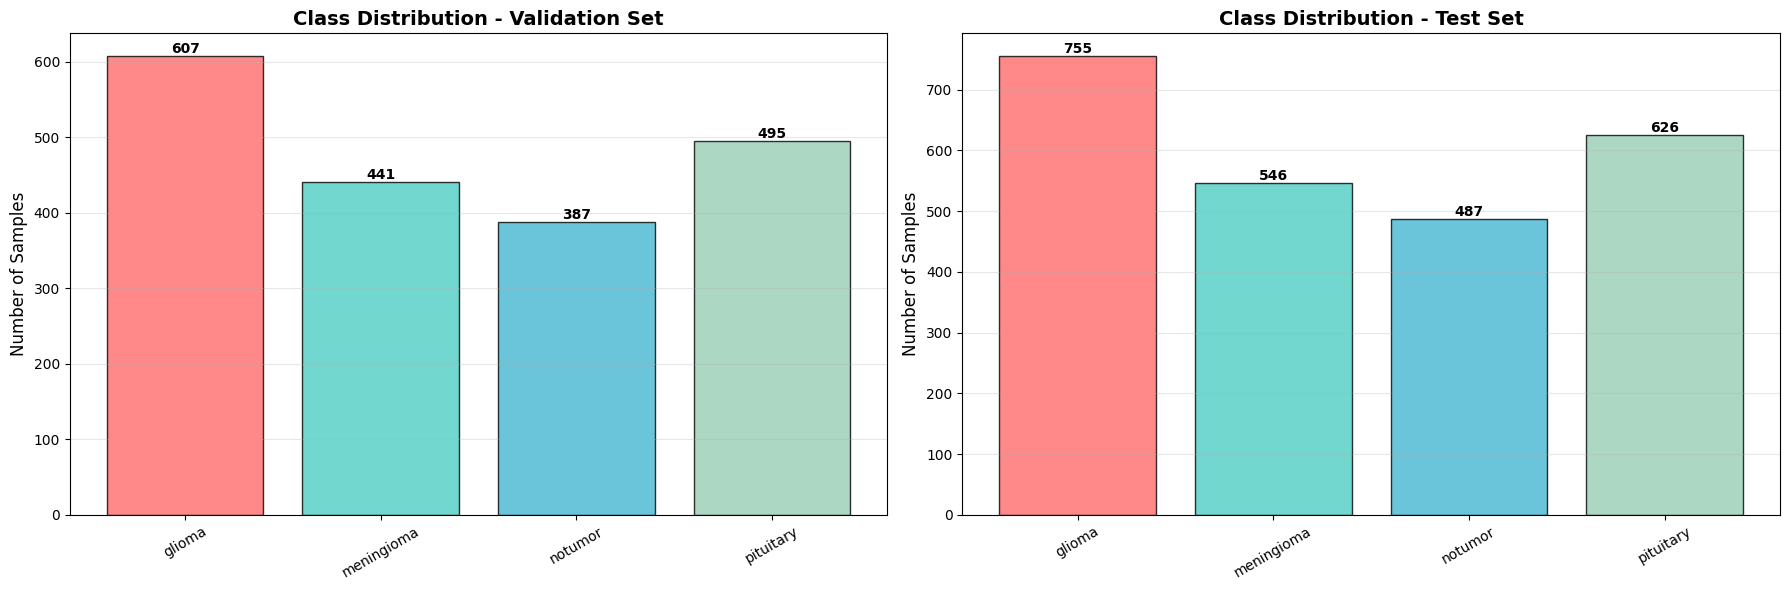

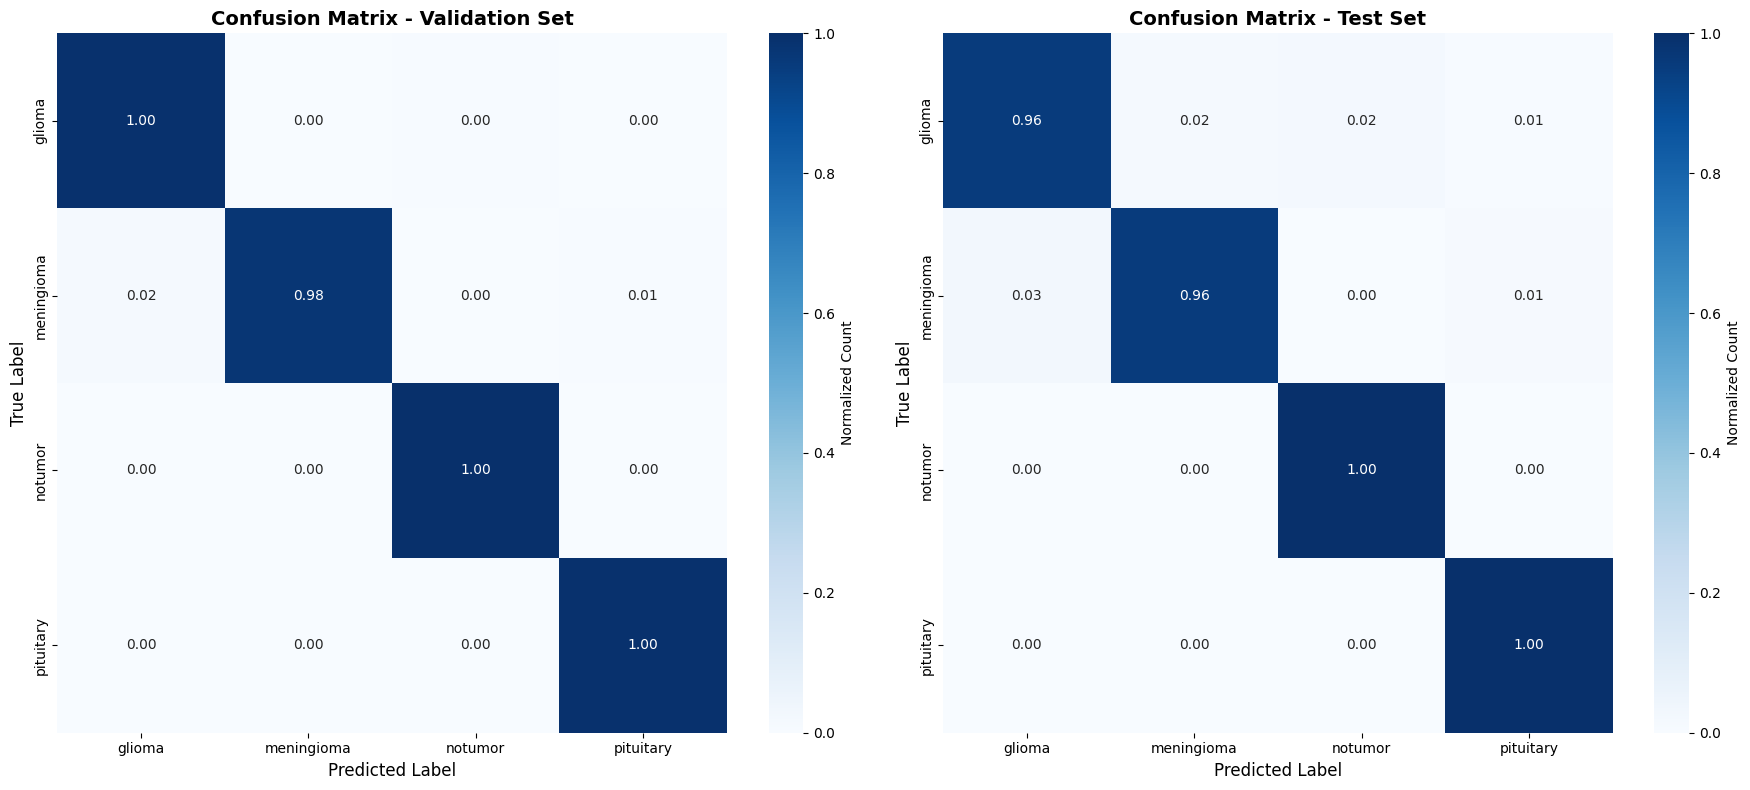

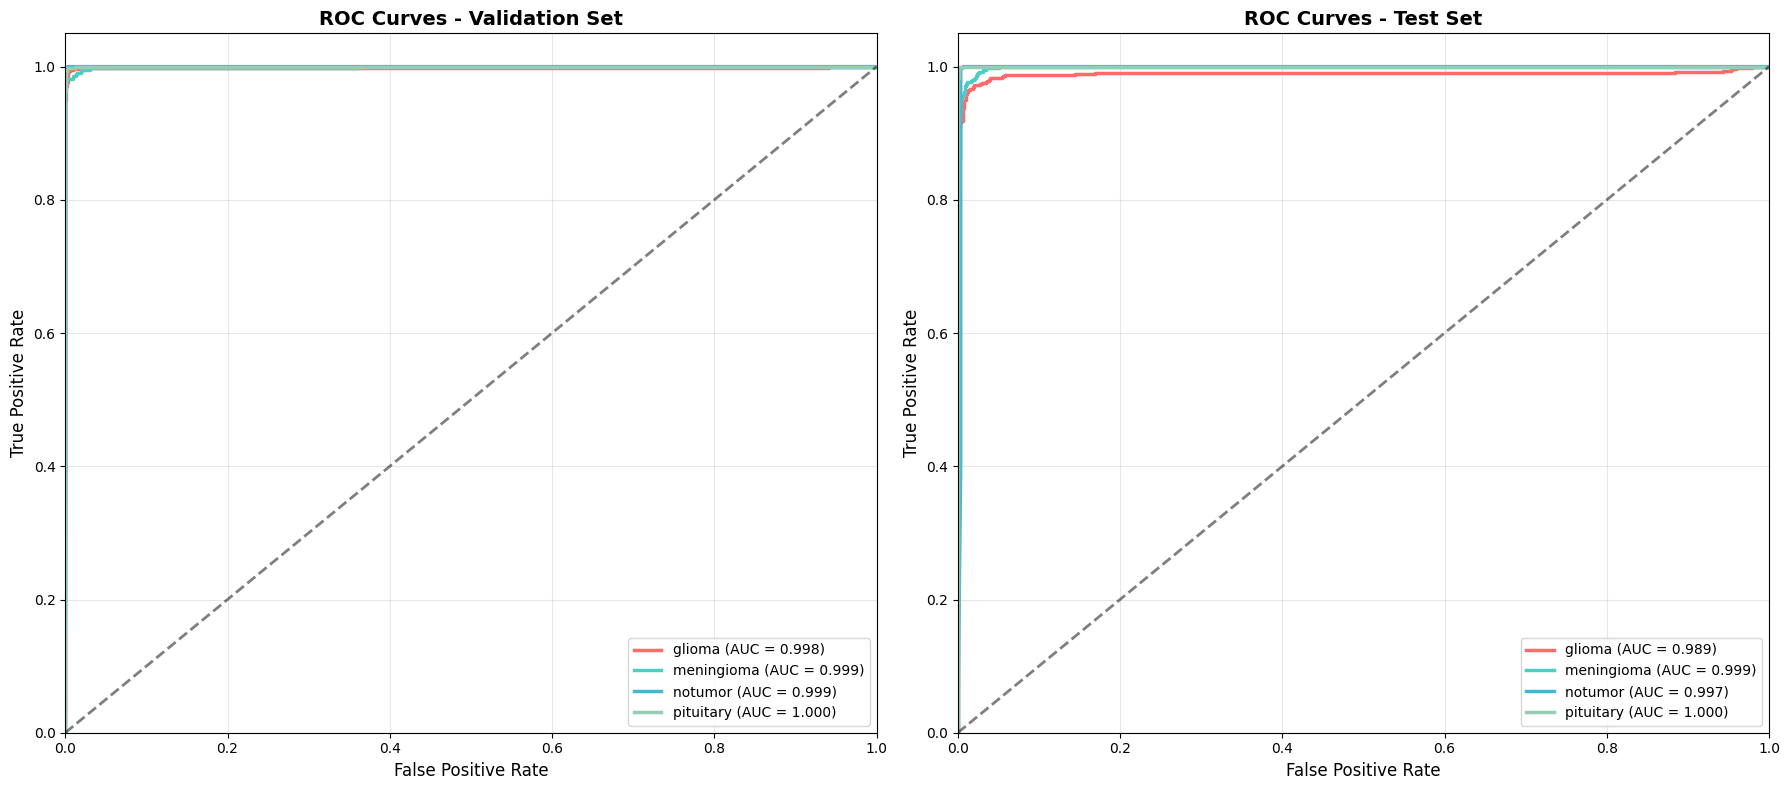

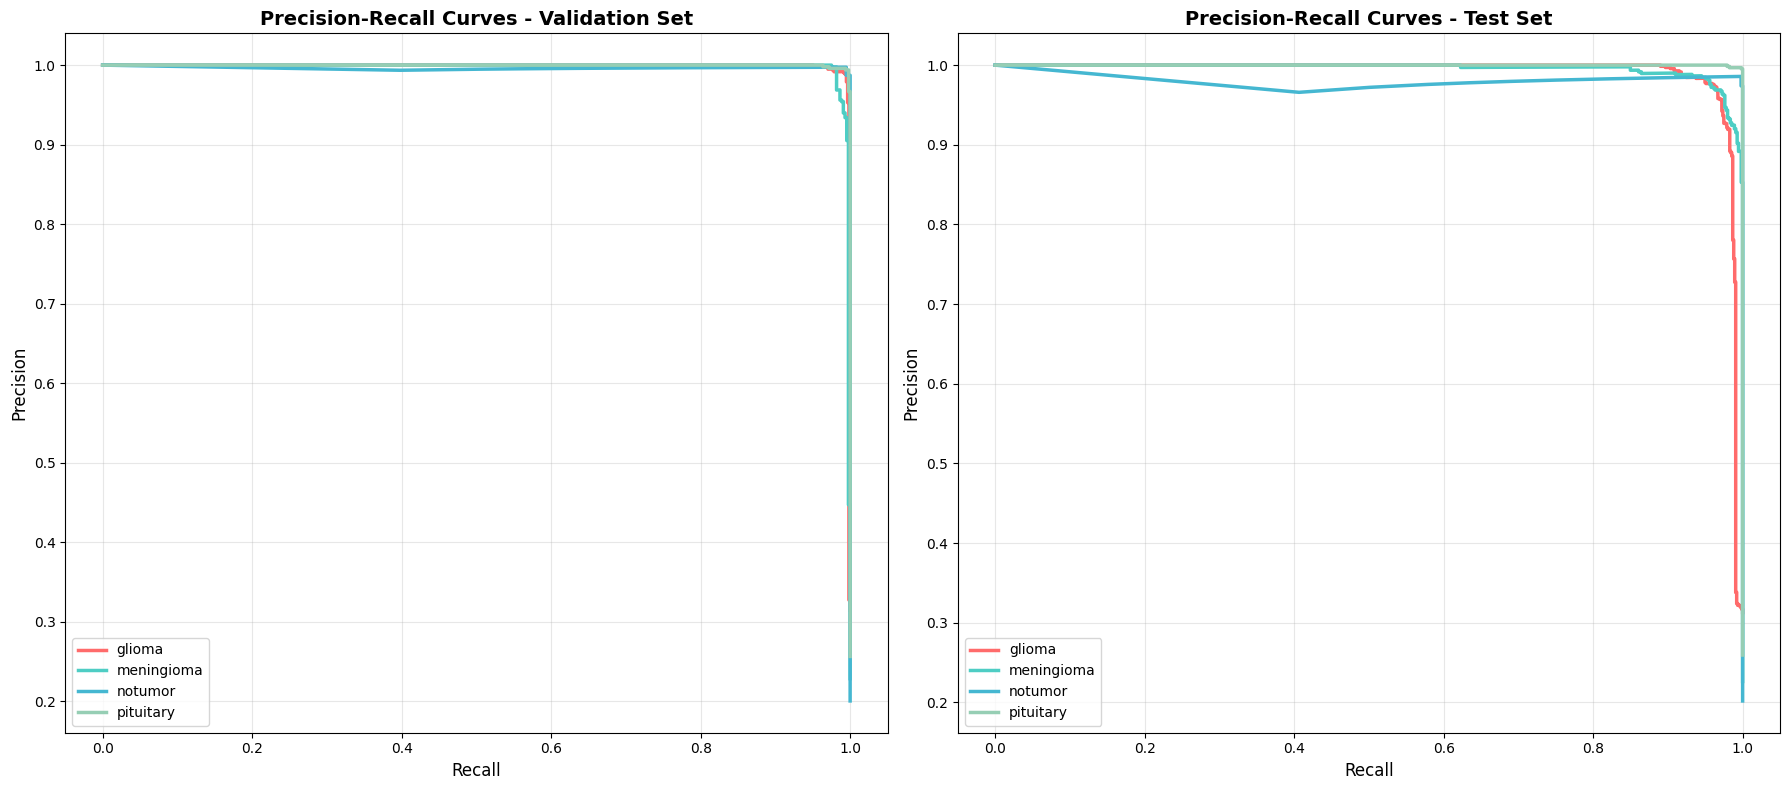

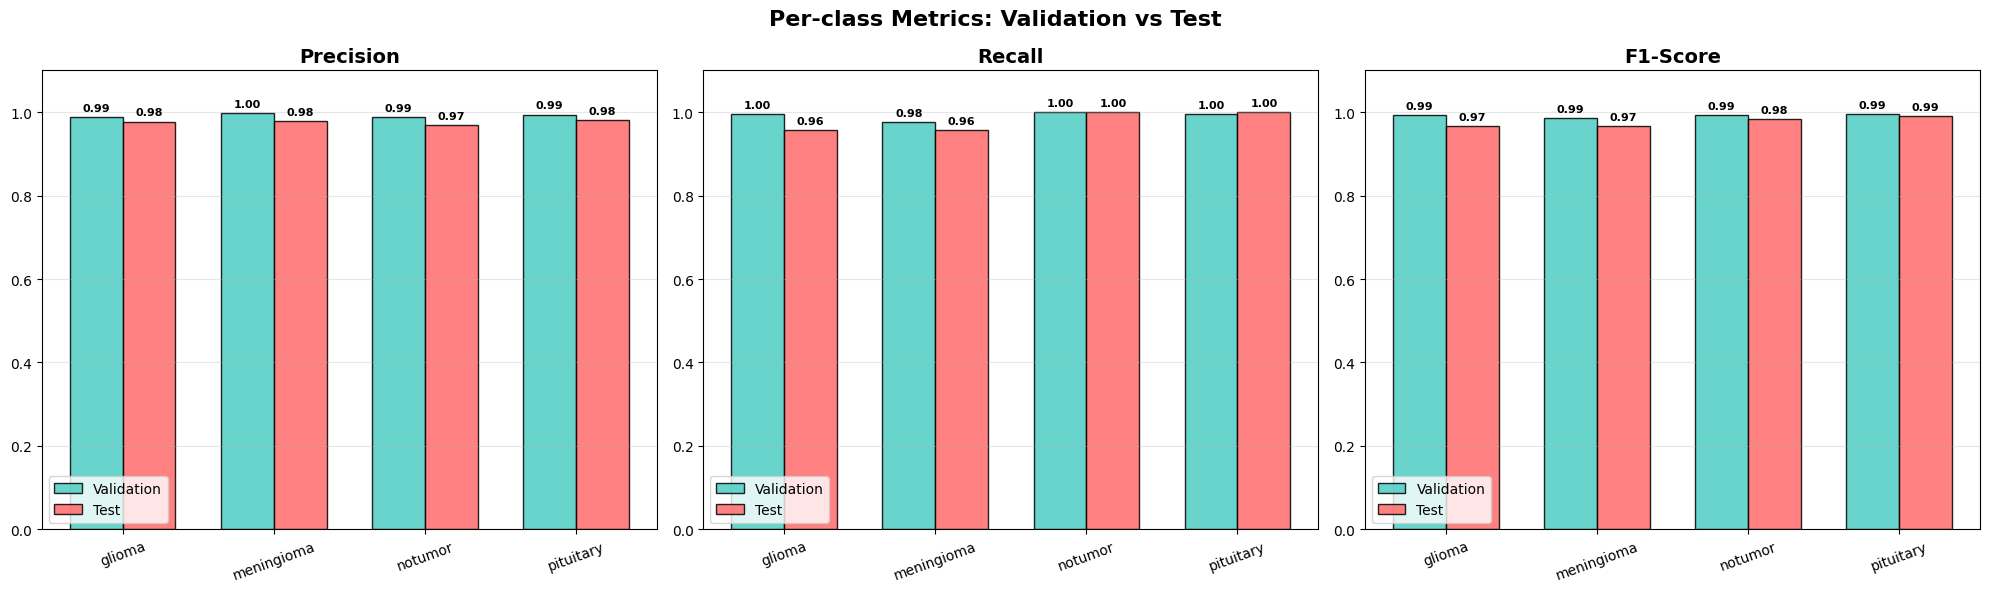

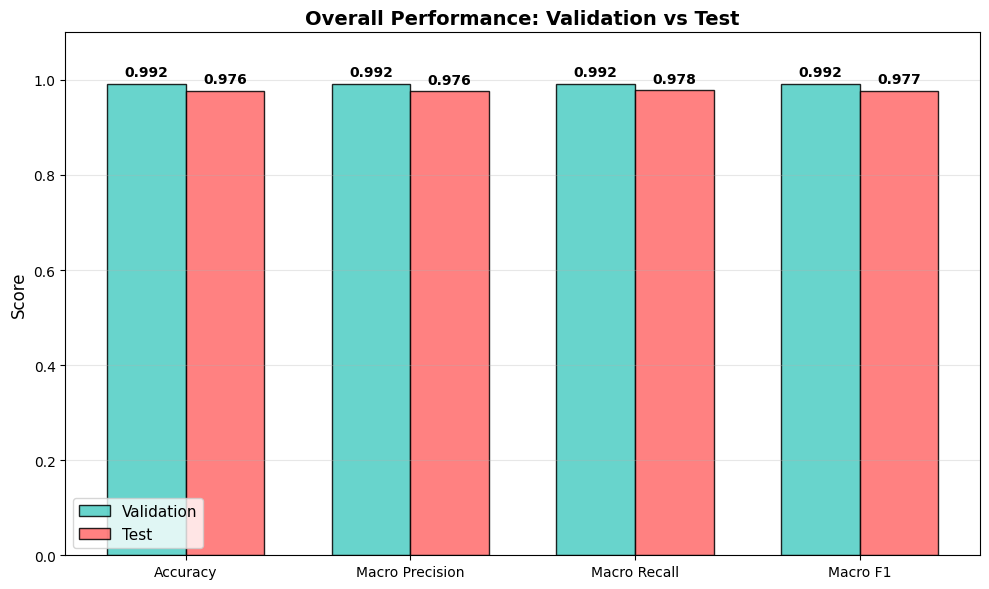


CLASSIFICATION REPORT — VALIDATION SET
              precision    recall  f1-score   support

      glioma      0.989     0.995     0.992       607
  meningioma      0.998     0.975     0.986       441
     notumor      0.987     1.000     0.994       387
   pituitary      0.994     0.996     0.995       495

    accuracy                          0.992      1930
   macro avg      0.992     0.992     0.992      1930
weighted avg      0.992     0.992     0.992      1930


CLASSIFICATION REPORT — TEST SET
              precision    recall  f1-score   support

      glioma      0.977     0.956     0.967       755
  meningioma      0.978     0.956     0.967       546
     notumor      0.968     1.000     0.984       487
   pituitary      0.981     1.000     0.991       626

    accuracy                          0.976      2414
   macro avg      0.976     0.978     0.977      2414
weighted avg      0.976     0.976     0.976      2414


✅ All visualizations saved to: D:\Master\Brain Tumor MR

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ============================
# إعدادات العرض
# ============================
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

# مجلد حفظ الصور
SAVE_DIR = Path("evaluation_results_val_vs_test")
SAVE_DIR.mkdir(exist_ok=True)

# إعداد الجهاز
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================
# دالة مساعدة للحفظ والعرض
# ============================
def save_and_show(filename):
    filepath = SAVE_DIR / filename
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

# ============================
# فئة مجموعة البيانات
# ============================
class BrainTumorMRIDataset(Dataset):
    """
    نسخة عامة تدعم القراءة من أي مجلد فرعي (Training أو Testing)
    وتدعم أيضاً إنشاء نسخ فرعية (subset) بنفس منطق سكربت التدريب،
    لضمان القدرة على إعادة إنتاج تقسيم Validation بدقة.
    """
    def __init__(self, data_dir, split_folder="Training", transform=None):
        self.data_dir = Path(data_dir)
        self.split_folder = split_folder
        self.transform = transform

        self.class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
        self.class_to_idx = {name: idx for idx, name in enumerate(self.class_names)}

        self.samples = []
        self._scan_directory()

    def _scan_directory(self):
        # يجب أن يطابق تماماً منطق المسح في سكربت التدريب:
        # نفس ترتيب class_names، نفس glob('*') بدون ترتيب إضافي،
        # مع إزالة التكرار (seen_paths) كما في سكربت التدريب.
        folder = self.data_dir / self.split_folder
        seen_paths = set()
        if folder.exists():
            for class_name in self.class_names:
                class_folder = folder / class_name
                if class_folder.exists():
                    label = self.class_to_idx[class_name]
                    for img_path in class_folder.glob('*'):
                        if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                            img_path_str = str(img_path.resolve())
                            if img_path_str not in seen_paths:
                                seen_paths.add(img_path_str)
                                self.samples.append((img_path_str, label))
        else:
            print(f"❌ Folder not found: {folder}")

    def print_class_distribution(self, title=""):
        class_counts = [0] * len(self.class_names)
        for _, label in self.samples:
            class_counts[label] += 1
        print(f"📊 Class Distribution {title}:")
        for class_name, count in zip(self.class_names, class_counts):
            print(f"  {class_name}: {count} images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception:
            black_img = Image.new('RGB', (128, 128), (0, 0, 0))
            if self.transform:
                return self.transform(black_img), label
            return torch.zeros(3, 128, 128), label


def build_validation_split(data_dir, val_transform, train_split=0.8, seed=42):
    """
    يعيد إنتاج نفس تقسيم Validation المستخدم أثناء التدريب بالضبط:
    - نفس مسح مجلد Training بنفس الترتيب
    - نفس seed = 42
    - نفس منطق shuffle + train_size = int(0.8 * total)
    - val_indices = indices[train_size:]
    """
    full_dataset = BrainTumorMRIDataset(data_dir, split_folder="Training", transform=None)
    total_size = len(full_dataset)
    train_size = int(train_split * total_size)

    indices = list(range(total_size))
    np.random.seed(seed)
    np.random.shuffle(indices)

    val_indices = indices[train_size:]
    val_samples = [full_dataset.samples[i] for i in val_indices]

    val_dataset = BrainTumorMRIDataset.__new__(BrainTumorMRIDataset)
    val_dataset.data_dir = full_dataset.data_dir
    val_dataset.split_folder = "Training (validation subset)"
    val_dataset.transform = val_transform
    val_dataset.class_names = full_dataset.class_names
    val_dataset.class_to_idx = full_dataset.class_to_idx
    val_dataset.samples = val_samples

    print(f"📈 Full Training pool: {total_size} images")
    print(f"📊 Validation subset (last {total_size - train_size}): {len(val_dataset)} images")

    return val_dataset


# ============================
# مكونات براءة الاختراع (بدون تغيير)
# ============================
# ============================
# Patent Components
# ============================
class MicroAdaptiveFeatureExtractor(nn.Module):
    """
    MAFE - Parallel version (Eq. 3.2-3.4)
    Spatial and channel attention are both computed directly from x
    (not sequentially), then combined multiplicatively.
    """
    def __init__(self, channels, reduction=16):
        super().__init__()
        reduced_ch = max(1, channels // reduction)

        self.spatial_conv = nn.Conv2d(channels, 1, 1)
        self.channel_avg = nn.AdaptiveAvgPool2d(1)
        self.channel_fc = nn.Conv2d(channels, reduced_ch, 1)
        self.channel_out = nn.Conv2d(reduced_ch, channels, 1)
        self.alpha = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        # Both branches computed independently from the original x (parallel)
        spatial_weights = torch.sigmoid(self.spatial_conv(x))                 # Ws from x

        channel_pool = self.channel_avg(x)                                     # from x, not x_spatial
        channel_weights = torch.sigmoid(self.channel_out(F.relu(self.channel_fc(channel_pool))))  # Wc from x

        x_enhanced = x * spatial_weights * channel_weights                     # x · Ws · Wc combined

        return x + self.alpha * x_enhanced

class MicroMultiScaleProcessor(nn.Module):
    def __init__(self, channels):
        super().__init__()
        inter = max(8, channels // 4)
        while inter % 4 != 0 and inter > 4:
            inter -= 1
        if inter < 4:
            inter = 4

        self.scale1 = nn.Conv2d(channels, inter, 1, bias=False)
        self.scale3 = nn.Conv2d(channels, inter, 3, padding=1, bias=False)

        if channels >= 8 and inter >= 4:
            groups = 1
            for g in [8, 4, 2]:
                if channels % g == 0:
                    groups = g
                    break
            self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, groups=groups, bias=False)
        else:
            self.scale3dw = nn.Conv2d(channels, inter, 3, padding=1, bias=False)

        self.fusion = nn.Conv2d(inter * 3, channels, 1, bias=False)
        self.beta = nn.Parameter(torch.tensor(0.3), requires_grad=True)

    def forward(self, x):
        s1 = F.relu(self.scale1(x))
        s3 = F.relu(self.scale3(x))
        s3dw = F.relu(self.scale3dw(x))

        combined = torch.cat([s1, s3, s3dw], dim=1)
        fused = self.fusion(combined)

        return F.relu(x + self.beta * fused)

class MicroIntelligentPooling(nn.Module):
    """
    CAIP - Context-Aware Intelligent Pooling (Eq. 3.9-3.12)
    A spatial context map (same H×W as input) reweights x before pooling,
    so the pooling decision is context-aware rather than a single global
    scalar decision per image.
    """
    def __init__(self, channels):
        super().__init__()
        reduced_ch = max(4, channels // 4)

        # Context Analysis network - preserves spatial dimensions
        self.context_net = nn.Sequential(
            nn.Conv2d(channels, reduced_ch, 1),
            nn.BatchNorm2d(reduced_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(reduced_ch, reduced_ch, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(reduced_ch, channels, 3, padding=1),
            nn.Sigmoid()
        )

        self.lam = nn.Parameter(torch.tensor(0.5), requires_grad=True)  # learnable λ

    def forward(self, x):
        context = self.context_net(x)          # context map, same shape as x
        x_weighted = context * x                # Context ⊗ x

        y_max = F.max_pool2d(x_weighted, kernel_size=2, stride=2)
        y_avg = F.avg_pool2d(x_weighted, kernel_size=2, stride=2)

        lam_clamped = torch.sigmoid(self.lam)   # constrain λ to [0, 1]
        return lam_clamped * y_max + (1 - lam_clamped) * y_avg

# ============================
# Main Model
# ============================
class UltraLightPatentBrainTumorCNN(nn.Module):
    def __init__(self, num_classes=4, base_channels=[32, 64, 128, 256]):
        super().__init__()
        c1, c2, c3, c4 = base_channels

        print(f"🏗️ Building model with channels: {base_channels}")

        self.conv1 = nn.Conv2d(3, c1, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(c1)
        self.adaptive1 = MicroAdaptiveFeatureExtractor(c1, reduction=4)
        self.pool1 = MicroIntelligentPooling(c1)

        self.conv2 = nn.Conv2d(c1, c2, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(c2)
        self.multiscale2 = MicroMultiScaleProcessor(c2)
        self.pool2 = MicroIntelligentPooling(c2)

        self.conv3 = nn.Conv2d(c2, c3, 3, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(c3)
        self.adaptive3 = MicroAdaptiveFeatureExtractor(c3, reduction=8)
        self.pool3 = MicroIntelligentPooling(c3)

        self.conv4 = nn.Conv2d(c3, c4, 3, padding=1, bias=False)
        self.bn4 = nn.BatchNorm2d(c4)
        self.multiscale4 = MicroMultiScaleProcessor(c4)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(c4, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

        self._init_weights()
        print(f"✅ Model built successfully!")

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.)

    def forward(self, x):
        # Stage 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.adaptive1(x)
        x = self.pool1(x)

        # Stage 2
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.multiscale2(x)
        x = self.pool2(x)

        # Stage 3
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.adaptive3(x)
        x = self.pool3(x)

        # Stage 4
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.multiscale4(x)

        return self.classifier(x)

# ============================
# Training Functions (GPU-optimized)
# ============================
def train_epoch(model, dataloader, optimizer, criterion, device, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1} - Training", ncols=100)

    for batch_idx, (data, targets) in enumerate(progress_bar):
        # لا نستدعي empty_cache داخل الحلقة: يجبر PyTorch على إعادة تخصيص
        # الذاكرة كل batch ويبطئ التنفيذ بدل تسريعه.
        data, targets = data.to(device, non_blocking=True), targets.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

        # Update progress bar
        acc = 100. * correct / total
        progress_bar.set_postfix({
            'Loss': f'{loss.item():.3f}',
            'Acc': f'{acc:.1f}%'
        })

        del outputs, loss

    if device.type == 'cuda':
        torch.cuda.empty_cache()

    return running_loss / len(dataloader), 100. * correct / total

# ============================
# دوال التقييم
# ============================
def load_model(model_path, device):
    model = UltraLightPatentBrainTumorCNN(num_classes=4).to(device)
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print(f"✅ Model loaded successfully from {model_path}")
    return model, checkpoint


def evaluate_model(model, dataloader, device):
    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)

            all_probs.extend(probs.cpu().numpy())
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    return np.array(all_targets), np.array(all_preds), np.array(all_probs)


def create_test_transforms(image_size=128):
    return transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])


# ============================
# دوال التصور المقارنة (Validation vs Test)
# ============================
def compute_metrics(targets, preds):
    return {
        'accuracy': accuracy_score(targets, preds),
        'precision': precision_score(targets, preds, average=None),
        'recall': recall_score(targets, preds, average=None),
        'f1': f1_score(targets, preds, average=None),
        'macro_precision': precision_score(targets, preds, average='macro'),
        'macro_recall': recall_score(targets, preds, average='macro'),
        'macro_f1': f1_score(targets, preds, average='macro'),
    }


def plot_confusion_matrices_side_by_side(val_targets, val_preds, test_targets, test_preds, class_names):
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    for ax, targets, preds, title in [
        (axes[0], val_targets, val_preds, 'Validation Set'),
        (axes[1], test_targets, test_preds, 'Test Set'),
    ]:
        cm = confusion_matrix(targets, preds)
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=class_names, yticklabels=class_names,
                    cbar_kws={'label': 'Normalized Count'}, ax=ax)
        ax.set_title(f'Confusion Matrix - {title}', fontsize=14, fontweight='bold')
        ax.set_ylabel('True Label', fontsize=12)
        ax.set_xlabel('Predicted Label', fontsize=12)

    plt.tight_layout()
    save_and_show("01_confusion_matrix_val_vs_test.png")


def plot_roc_curves_side_by_side(val_targets, val_probs, test_targets, test_probs, class_names):
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

    for ax, targets, probs, title in [
        (axes[0], val_targets, val_probs, 'Validation Set'),
        (axes[1], test_targets, test_probs, 'Test Set'),
    ]:
        targets_bin = label_binarize(targets, classes=range(len(class_names)))
        for i in range(len(class_names)):
            fpr, tpr, _ = roc_curve(targets_bin[:, i], probs[:, i])
            roc_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=colors[i], lw=2.5,
                    label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

        ax.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate', fontsize=12)
        ax.set_ylabel('True Positive Rate', fontsize=12)
        ax.set_title(f'ROC Curves - {title}', fontsize=14, fontweight='bold')
        ax.legend(loc="lower right", fontsize=10)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    save_and_show("02_roc_curves_val_vs_test.png")


def plot_pr_curves_side_by_side(val_targets, val_probs, test_targets, test_probs, class_names):
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

    for ax, targets, probs, title in [
        (axes[0], val_targets, val_probs, 'Validation Set'),
        (axes[1], test_targets, test_probs, 'Test Set'),
    ]:
        targets_bin = label_binarize(targets, classes=range(len(class_names)))
        for i in range(len(class_names)):
            precision, recall, _ = precision_recall_curve(targets_bin[:, i], probs[:, i])
            ax.plot(recall, precision, color=colors[i], lw=2.5, label=f'{class_names[i]}')

        ax.set_xlabel('Recall', fontsize=12)
        ax.set_ylabel('Precision', fontsize=12)
        ax.set_title(f'Precision-Recall Curves - {title}', fontsize=14, fontweight='bold')
        ax.legend(loc="lower left", fontsize=10)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    save_and_show("03_precision_recall_curves_val_vs_test.png")


def plot_per_class_metrics_grouped(val_metrics, test_metrics, class_names):
    """يعرض لكل مقياس (Precision/Recall/F1) مقارنة Validation vs Test لكل صنف"""
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    metric_names = ['precision', 'recall', 'f1']
    titles = ['Precision', 'Recall', 'F1-Score']

    x = np.arange(len(class_names))
    width = 0.35

    for ax, metric_key, title in zip(axes, metric_names, titles):
        val_vals = val_metrics[metric_key]
        test_vals = test_metrics[metric_key]

        bars1 = ax.bar(x - width/2, val_vals, width, label='Validation', color='#4ECDC4', alpha=0.85, edgecolor='black')
        bars2 = ax.bar(x + width/2, test_vals, width, label='Test', color='#FF6B6B', alpha=0.85, edgecolor='black')

        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(class_names, rotation=20)
        ax.set_ylim([0, 1.1])
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')

        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{height:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    plt.suptitle('Per-class Metrics: Validation vs Test', fontsize=16, fontweight='bold')
    plt.tight_layout()
    save_and_show("04_per_class_metrics_val_vs_test.png")


def plot_overall_accuracy_comparison(val_metrics, test_metrics):
    fig, ax = plt.subplots(figsize=(10, 6))

    labels = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1']
    val_values = [val_metrics['accuracy'], val_metrics['macro_precision'],
                  val_metrics['macro_recall'], val_metrics['macro_f1']]
    test_values = [test_metrics['accuracy'], test_metrics['macro_precision'],
                   test_metrics['macro_recall'], test_metrics['macro_f1']]

    x = np.arange(len(labels))
    width = 0.35

    bars1 = ax.bar(x - width/2, val_values, width, label='Validation', color='#4ECDC4', alpha=0.85, edgecolor='black')
    bars2 = ax.bar(x + width/2, test_values, width, label='Test', color='#FF6B6B', alpha=0.85, edgecolor='black')

    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Overall Performance: Validation vs Test', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim([0, 1.1])
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    save_and_show("05_overall_accuracy_val_vs_test.png")


def plot_class_distribution_side_by_side(val_targets, test_targets, class_names):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

    for ax, targets, title in [
        (axes[0], val_targets, 'Validation Set'),
        (axes[1], test_targets, 'Test Set'),
    ]:
        class_counts = [np.sum(targets == i) for i in range(len(class_names))]
        bars = ax.bar(class_names, class_counts, color=colors, alpha=0.8, edgecolor='black')
        ax.set_title(f'Class Distribution - {title}', fontsize=14, fontweight='bold')
        ax.set_ylabel('Number of Samples', fontsize=12)
        ax.tick_params(axis='x', rotation=30)
        ax.grid(True, alpha=0.3, axis='y')
        for bar, count in zip(bars, class_counts):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{count}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    save_and_show("06_class_distribution_val_vs_test.png")


def print_comparison_report(val_targets, val_preds, test_targets, test_preds, class_names):
    print("\n" + "="*70)
    print("CLASSIFICATION REPORT — VALIDATION SET")
    print("="*70)
    print(classification_report(val_targets, val_preds, target_names=class_names, digits=3))

    print("\n" + "="*70)
    print("CLASSIFICATION REPORT — TEST SET")
    print("="*70)
    print(classification_report(test_targets, test_preds, target_names=class_names, digits=3))
    print("="*70)


# ============================
# البرنامج الرئيسي
# ============================
def main():
    print("="*60)
    print("BRAIN TUMOR MODEL — VALIDATION vs TEST COMPARISON")
    print("="*60)
    print(f"📁 Results will be saved to: {SAVE_DIR.resolve()}")

    MODEL_PATH = "best_brain_tumor_model_patent.pth"
    DATA_DIR = "Brain Tumor MRI Dataset Big"

    if not Path(MODEL_PATH).exists():
        print(f"❌ Model file not found: {MODEL_PATH}")
        return

    print(f"\n📥 Loading model from: {MODEL_PATH}")
    model, checkpoint = load_model(MODEL_PATH, device)

    class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
    print(f"📋 Classes: {class_names}")

    eval_transform = create_test_transforms(128)

    # ---- إعادة إنتاج مجموعة الـ Validation بنفس منطق التدريب ----
    print(f"\n📂 Rebuilding Validation split from: {DATA_DIR}/Training (seed=42, split=0.8)")
    val_dataset = build_validation_split(DATA_DIR, val_transform=eval_transform,
                                          train_split=0.8, seed=42)
    val_dataset.print_class_distribution("(Validation)")
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

    # ---- تحميل مجموعة الـ Test ----
    print(f"\n📂 Loading Test data from: {DATA_DIR}/Testing")
    test_dataset = BrainTumorMRIDataset(DATA_DIR, split_folder="Testing", transform=eval_transform)
    test_dataset.print_class_distribution("(Test)")
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

    # ---- التقييم على المجموعتين ----
    print(f"\n🔄 Evaluating on Validation set...")
    val_targets, val_preds, val_probs = evaluate_model(model, val_loader, device)

    print(f"🔄 Evaluating on Test set...")
    test_targets, test_preds, test_probs = evaluate_model(model, test_loader, device)

    val_metrics = compute_metrics(val_targets, val_preds)
    test_metrics = compute_metrics(test_targets, test_preds)

    print(f"\n" + "="*60)
    print(f"✅ RESULTS SUMMARY")
    print(f"="*60)
    print(f"Validation — Accuracy: {val_metrics['accuracy']:.4f} ({val_metrics['accuracy']*100:.2f}%) | Samples: {len(val_targets)}")
    print(f"Test       — Accuracy: {test_metrics['accuracy']:.4f} ({test_metrics['accuracy']*100:.2f}%) | Samples: {len(test_targets)}")
    gap = (val_metrics['accuracy'] - test_metrics['accuracy']) * 100
    print(f"Gap (Val - Test): {gap:+.2f} percentage points")
    print(f"="*60)

    print(f"\n📊 Generating comparison visualizations...\n")

    plot_class_distribution_side_by_side(val_targets, test_targets, class_names)
    plot_confusion_matrices_side_by_side(val_targets, val_preds, test_targets, test_preds, class_names)
    plot_roc_curves_side_by_side(val_targets, val_probs, test_targets, test_probs, class_names)
    plot_pr_curves_side_by_side(val_targets, val_probs, test_targets, test_probs, class_names)
    plot_per_class_metrics_grouped(val_metrics, test_metrics, class_names)
    plot_overall_accuracy_comparison(val_metrics, test_metrics)

    print_comparison_report(val_targets, val_preds, test_targets, test_preds, class_names)

    print(f"\n✅ All visualizations saved to: {SAVE_DIR.resolve()}")
    print(f"🎉 Validation vs Test comparison finished successfully!")


if __name__ == "__main__":
    main()